<h1 align="center"><b>Trabalho II - Ciência de Dados II</b></h1>

**Integrantes**:
- Daniela Alessandra Prill
- Leonardo Moschetta dos Santos
- Miguel dos Santos Baggio
- Vitor Dallabona

---

**Aplicativos Alvo**:
- **Aplicativos de Delivery**: *iFood, Delivery Much, Zé Delivery e Pigz*

---

##  **Coleta de Dados**

Para realizar a coleta dos dados, será utilizado a biblioteca ```Google-Play-Scraper``` para um DataFrame Pandas.

In [ ]:
!pip install google-play-scraper pandas # instalação das bibliotecas Google-play-scraper e Pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd

Para obter os dados, usamos o ID do aplicativo (na URL da Play Store, logo após ```id=```):

- **iFood**: _br.com.brainweb.ifood_
- **Delivery Much**: _com.deliverymuch.app_
- **Zé Delivery**: _com.ambev.zedelivery_
- **Pigz**: _app.pigz.mart_

_Obs._: Iríamos fazer uso também do **99**, porém como o aplicativo engloba também corridas, além de entregas, resolvemos não fazer uso.

A principal função que será usada é ```reviews```, na qual permite obter as _reviews_ mais recentes, permitindo escolher o idioma, país, a ordenação e o número de comentários.

In [ ]:
apps_alvo = { # id de cada aplicativo que será iterado
    'iFood': 'br.com.brainweb.ifood',
    'Delivery Much': 'br.com.deliverymuch.gastro',
    'Zé Delivery': 'com.cerveceriamodelo.modelonow',
    'Pigz': 'app.pigz.mart'
}

comentarios = []

for app_name, app_id in apps_alvo.items():
  print(f"Coletando comentários de {app_name}.")

  result, continuation_token = reviews( # retorna uma lista de dicionário e um token
      app_id,                           # id do aplicativo
      lang='pt',                        # comentários em português
      country='br',                     # país de origem
      sort=Sort.NEWEST,                 # pega os mais recentes
      count=200                         # quantidade de comentários que será extraído
  )

  # aplicativo fonte
  for review in result:
    review['app'] = app_name
    comentarios.append(review)

df = pd.DataFrame(comentarios)
print(f"Total de comentários: {len(df)}")

Coletando comentários de iFood.
Coletando comentários de Delivery Much.
Coletando comentários de Zé Delivery.
Coletando comentários de Pigz.
Total de comentários: 725


In [ ]:
df.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app
0,50775e1f-84b0-4260-bb5e-fdc1e7e14ff6,Juliana Beatriz,https://play-lh.googleusercontent.com/a-/ALV-U...,depois que inventaram ifood nem vou pra restau...,5,0,10.127.0,2026-06-23 16:32:49,None,NaT,10.127.0,iFood
1,5fcb01e4-25a9-4b43-a9d8-c576df202dd0,Simone Molhano,https://play-lh.googleusercontent.com/a-/ALV-U...,ifood e vida amo muito,5,0,10.127.0,2026-06-23 16:29:47,None,NaT,10.127.0,iFood
2,2c19fe5b-b9ba-45c2-8cd6-b24a0903f0cf,Silene Simões,https://play-lh.googleusercontent.com/a-/ALV-U...,Não está existindo a devolução do dinheiro qua...,2,0,10.127.0,2026-06-23 16:23:39,None,NaT,10.127.0,iFood
3,313745dd-5758-4a22-a2ff-d221dfe03476,Clarissa Nunes,https://play-lh.googleusercontent.com/a-/ALV-U...,O suporte deixou a desejar em vários momentos.,3,0,10.127.0,2026-06-23 16:15:21,None,NaT,10.127.0,iFood
4,d4596cd0-6faa-4af1-b94d-9d4821ac0bd8,claudinei meneghetti,https://play-lh.googleusercontent.com/a/ACg8oc...,muito prático e resolve a necessidade recomendo,5,0,10.127.0,2026-06-23 16:06:43,None,NaT,10.127.0,iFood


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              725 non-null    object        
 1   userName              725 non-null    object        
 2   userImage             725 non-null    object        
 3   content               725 non-null    object        
 4   score                 725 non-null    int64         
 5   thumbsUpCount         725 non-null    int64         
 6   reviewCreatedVersion  628 non-null    object        
 7   at                    725 non-null    datetime64[ns]
 8   replyContent          26 non-null     object        
 9   repliedAt             26 non-null     datetime64[ns]
 10  appVersion            628 non-null    object        
 11  app                   725 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 68.1+ KB


A função retorna várias colunas, então escolhemos apenas as de interesse.

In [ ]:
df_final = df[
    [
        'app',        # aplicativo de origem do comentário
        'content',    # comentário
        'score',      # nota do usuário
        'at',         # data da avaliação
]]
df_final.head()

,app,content,score,at
0,iFood,depois que inventaram ifood nem vou pra restau...,5,2026-06-23 16:32:49
1,iFood,ifood e vida amo muito,5,2026-06-23 16:29:47
2,iFood,Não está existindo a devolução do dinheiro qua...,2,2026-06-23 16:23:39
3,iFood,O suporte deixou a desejar em vários momentos.,3,2026-06-23 16:15:21
4,iFood,muito prático e resolve a necessidade recomendo,5,2026-06-23 16:06:43


In [ ]:
# renomeação das colunas

df_final.rename(columns={
    'app': 'aplicativo',
    'content': 'comentario',
    'score': 'nota',
    'at': 'data'
}, inplace=True)
df_final

,aplicativo,comentario,nota,data
0,iFood,depois que inventaram ifood nem vou pra restau...,5,2026-06-23 16:32:49
1,iFood,ifood e vida amo muito,5,2026-06-23 16:29:47
2,iFood,Não está existindo a devolução do dinheiro qua...,2,2026-06-23 16:23:39
3,iFood,O suporte deixou a desejar em vários momentos.,3,2026-06-23 16:15:21
4,iFood,muito prático e resolve a necessidade recomendo,5,2026-06-23 16:06:43
...,...,...,...,...
720,Pigz,Preços iguais aos da loja física,5,2020-12-31 05:05:53
721,Pigz,O app é excelente. Super fácil de usar e não p...,5,2020-12-30 01:11:15
722,Pigz,"Rápido, prático e fácil. 100% recomendado",5,2020-12-26 01:53:07
723,Pigz,Gostei. Baixei por causa do meu amigo/irmão mit,5,2020-12-21 20:37:42


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   aplicativo  725 non-null    object        
 1   comentario  725 non-null    object        
 2   nota        725 non-null    int64         
 3   data        725 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 22.8+ KB


In [ ]:
# exportação para CSV
df_final.to_csv('delivery_reviews.csv', index=False, encoding='utf-8')

No total, foi pego 725 comentários, **200*** comentários de cada aplicativo, incluindo o nome do aplicativo, o comentário, a nota da classificação (de 1 a 5) e a data do _review_.

---
_*O aplicativo *Pigz* possui menos que 200 avaliações com comentários, o que limitou o total de comentários do dataset._

## **Análise Exploratória (EDA) Inicial**

Aqui, vamos fazer uma análise e processamento dos textos/comentários obtidos. Inicialmente, será observado a distribuição das notas e comentários em cada aplicativo.

In [ ]:
# bibliotecas usadas
import matplotlib.pyplot as plt
import seaborn as sns

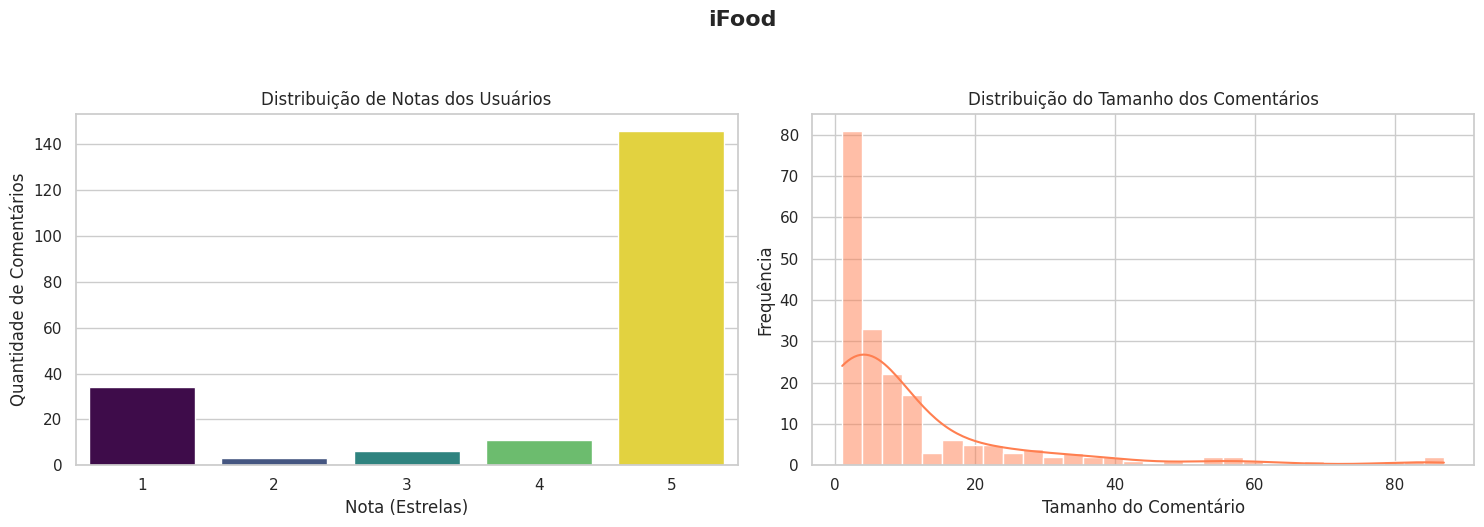

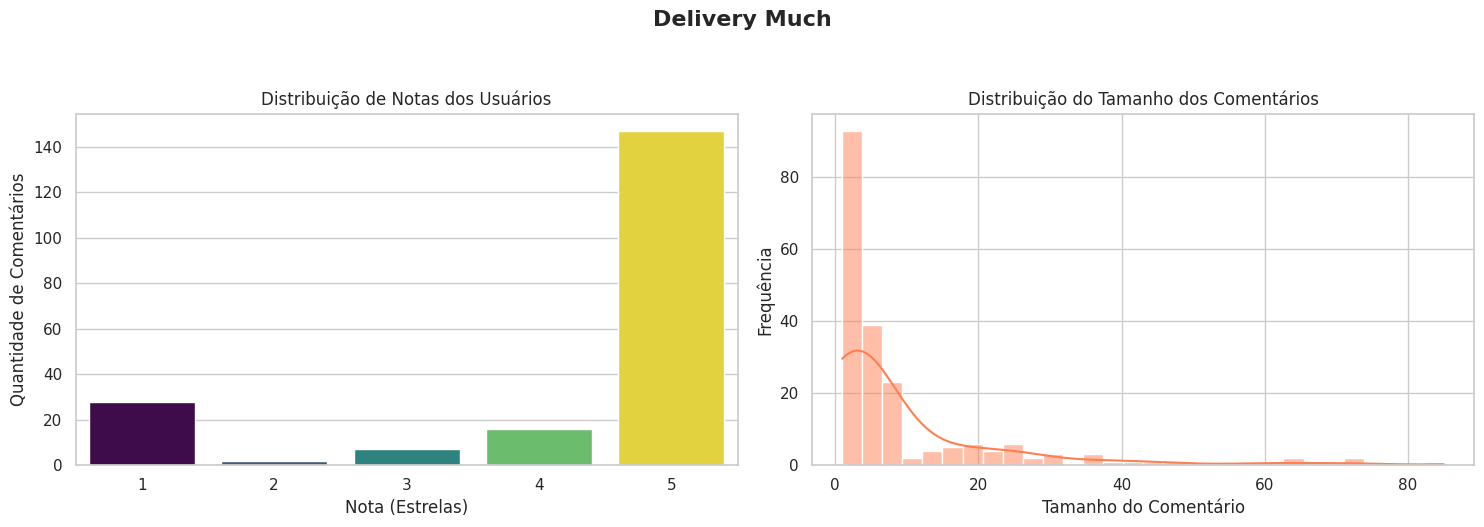

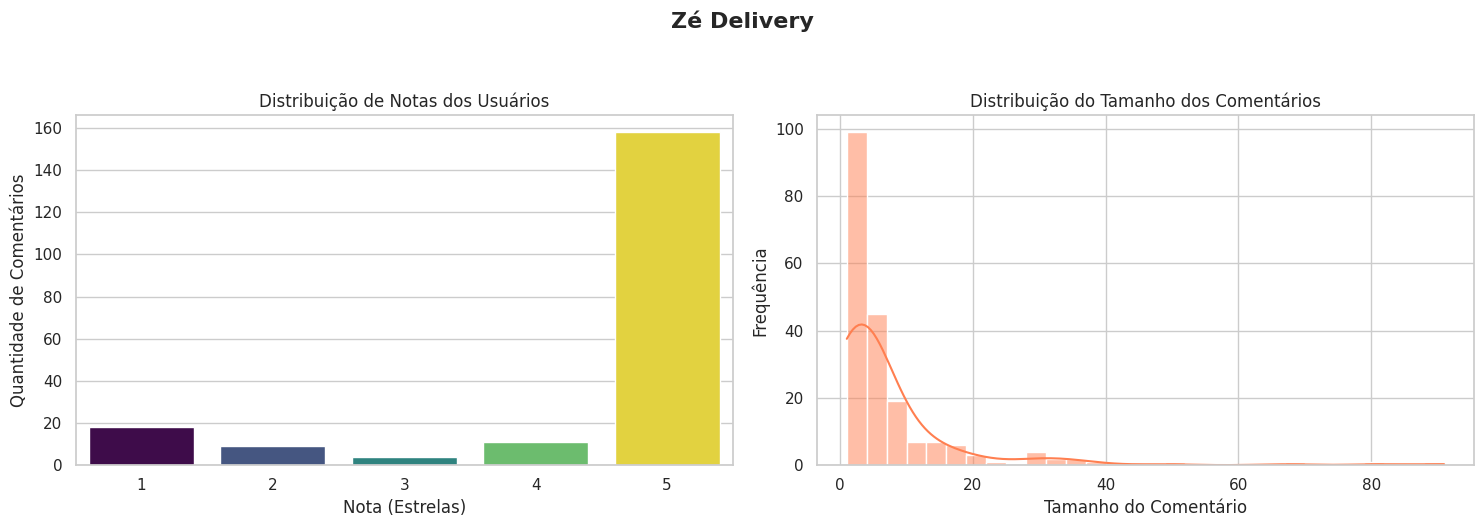

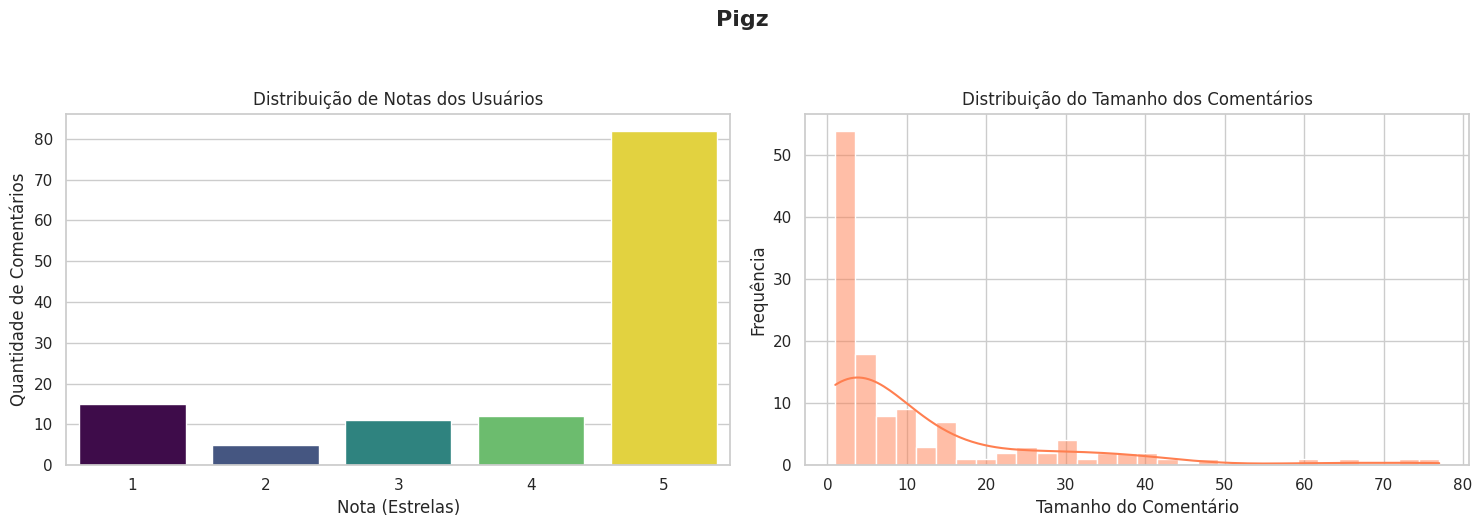

In [ ]:
df_final = pd.read_csv('delivery_reviews.csv')

# obtenção do tamanho do texto
df_final['tamanho_texto'] = df_final['comentario'].apply(lambda x: len(str(x).split()))

# config para geração dos gráficos
sns.set_theme(style="whitegrid") # tema dos gráficos

aplicativos = df_final['aplicativo'].unique()
for app in aplicativos:
  df_app = df_final[df_final['aplicativo'] == app]
  fig, axes = plt.subplots(1,2,figsize=(15,5))
  fig.suptitle(f'{app}', fontsize=16, fontweight='bold', y=1.05)

  # distribuição de notas
  sns.countplot(
      data=df_app,
      x='nota',
      ax=axes[0],
      palette='viridis',
      hue='nota',
      legend=False,
  )
  axes[0].set_title('Distribuição de Notas dos Usuários')
  axes[0].set_xlabel('Nota (Estrelas)')
  axes[0].set_ylabel('Quantidade de Comentários')

  # distribuição de tamanho do texto
  sns.histplot(
      data=df_app,
      bins=30, # qtd de barras
      kde=True, # plota o Kernel Density Estimate (KDE)
      x='tamanho_texto',
      color='coral',
      ax=axes[1],
  )
  axes[1].set_title('Distribuição do Tamanho dos Comentários')
  axes[1].set_xlabel('Tamanho do Comentário')
  axes[1].set_ylabel('Frequência')

  plt.tight_layout()
  plt.show()

No geral, os gráficos de notas mostra uma distribuição desbalanceada. A maior parte dos usuários avaliou com 5 estrelas e com 1 estrela. No geral, os usuários avaliam em situações mais críticas. Além disso, a maioria dos usuários escrevem poucas palavras, que muitas vezes não agregam contexto.

Nesse sentido, vamos remover os comentários com poucas palavras, com base em um limite inferior.

In [ ]:
limite_palavras=5
total_antes = len(df_final)
df_filtro = df_final[df_final['tamanho_texto'] >= limite_palavras].copy()

total_dps = len(df_filtro)
removidos = total_antes - total_dps
percentual_removido = (removidos/total_antes)*100

print(f"Total de comentários antes: {total_antes}")
print(f"Total de comentários depois: {total_dps}")
print(f"Total de comentários removidos: {removidos} ({percentual_removido:.2f}%)")

Total de comentários antes: 725
Total de comentários depois: 342
Total de comentários removidos: 383 (52.83%)


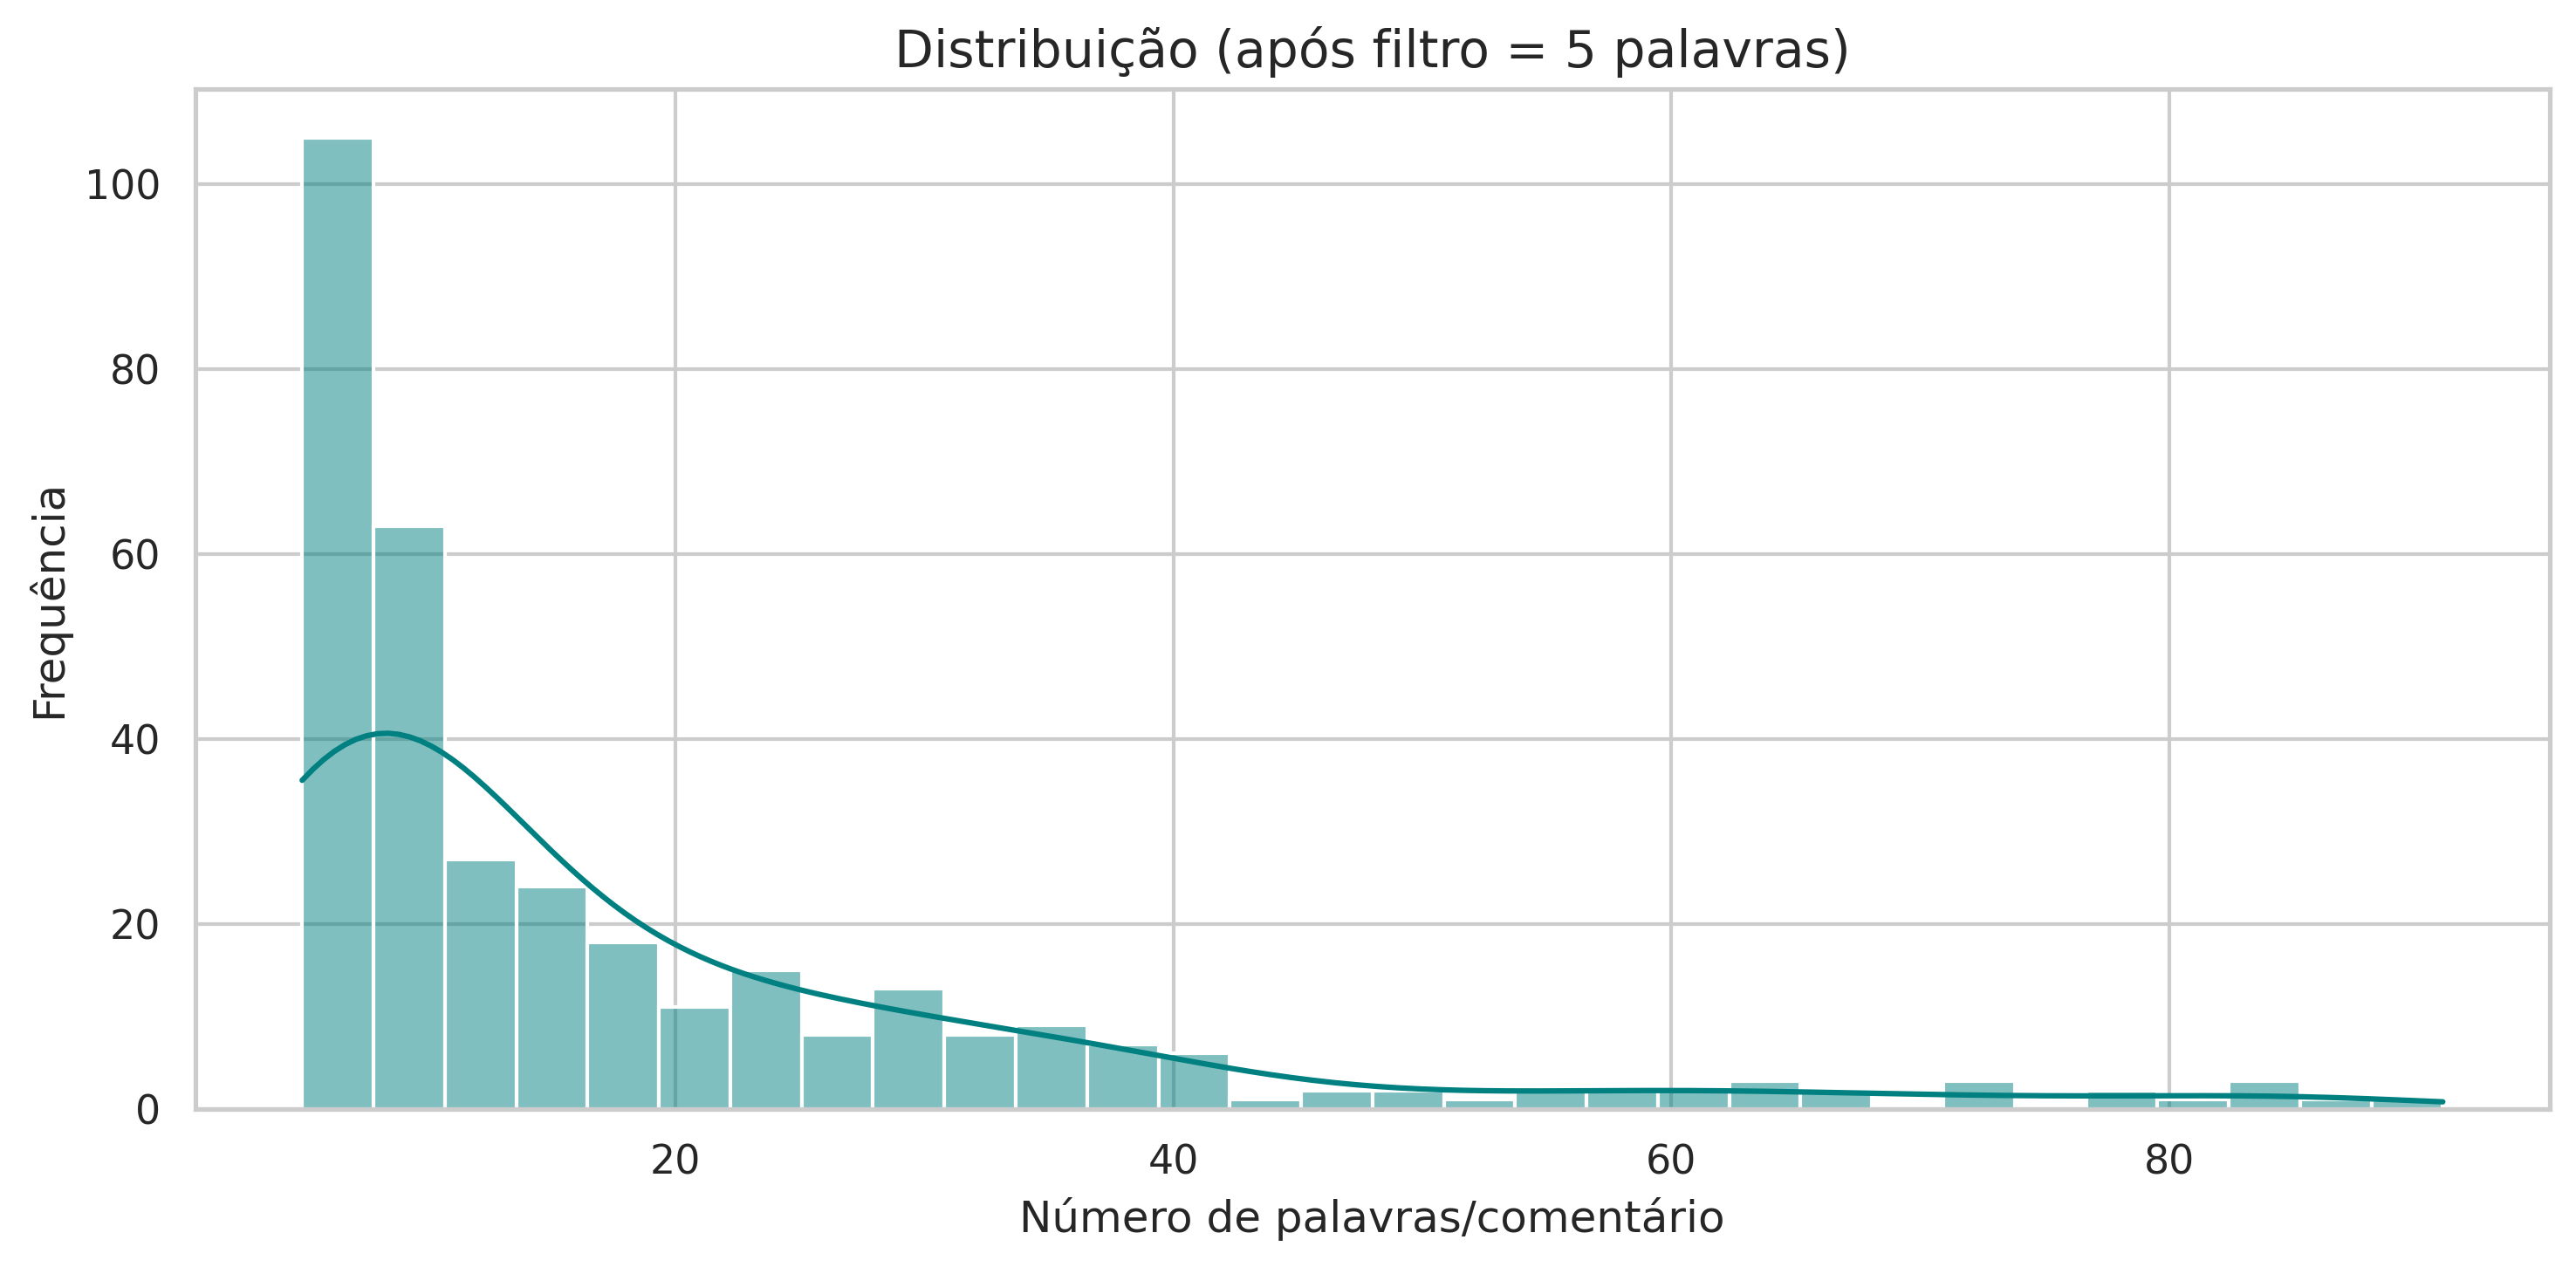

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=300)

# distribuição após filtro (total)
sns.histplot(
    data=df_filtro,
    bins=30,
    kde=True,
    x='tamanho_texto',
    color='teal'
)

# rótulos
plt.title('Distribuição (após filtro = 5 palavras)', fontsize=14)
plt.xlabel('Número de palavras/comentário')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

## **Pré-processamento dos Comentários**

In [ ]:
# bibliotecas necessárias

import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

In [ ]:
# pacotes necessários do NLTK

nltk.download('punkt')
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords')
nltk.download('rslp')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [ ]:
stop_words_portugues = stopwords.words('portuguese') # configuração de stopwords
stemmer_portugues = RSLPStemmer() # stemmer

In [ ]:
'''
  Função para pré-processamento de texto, obtida das aulas da disciplina
'''

def preprocess_text(text, remove_numbers=True, remove_punctuation=True,
                      remove_stopwords=True, apply_stemming=False):
    """
    Aplica um pipeline de pré-processamento a um texto usando NLTK e Regex.

    Args:
        text (str): O texto de entrada.
        remove_numbers (bool): Se True, remove números usando Regex.
        remove_punctuation (bool): Se True, remove pontuação usando string.punctuation.
        remove_stopwords (bool): Se True, remove stop words (do NLTK).
        apply_stemming (bool): Se True, aplica stemming RSLP (do NLTK).

    Returns:
        list: Uma lista de tokens pré-processados.
    """
    if not isinstance(text, str):
        return [] # Retorna lista vazia para entradas não string

    # 1. Converter para minúsculas
    text = text.lower()

    # 2. Remover URLs, mentions, hashtags (exemplos comuns com Regex)
    text = re.sub(r'https?://\S+', '', text) # Remove URLs (http, https)
    text = re.sub(r'@\w+', '', text) # Remove mentions (@usuario)
    text = re.sub(r'#\w+', '', text) # Remove hashtags (#hashtag)


    # 3. Remover números (se solicitado) usando Regex
    if remove_numbers:
        text = re.sub(r'\d+', '', text)

    # 4. Remover pontuação (se solicitado) usando string.punctuation
    if remove_punctuation:
         text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Remover espaços em branco extras usando Regex (e strip)
    text = re.sub(r'\s+', ' ', text).strip()

    # Certificar-se de que o texto não está vazio após a limpeza inicial
    if not text:
        return []

    # 6. Tokenização (NLTK)
    tokens = word_tokenize(text, language='portuguese')

    # 7. Remover stop words (se solicitado - NLTK)
    if remove_stopwords:
        tokens = [palavra for palavra in tokens if palavra not in stop_words_portugues]

    # 8. Aplicar stemming (se solicitado - NLTK)
    if apply_stemming:
        tokens = [stemmer_portugues.stem(palavra) for palavra in tokens]

    # Opcional: Remover tokens vazios ou de 1 caractere que podem ter sobrado
    tokens = [token for token in tokens if token and len(token) > 1]

    return tokens

### _Remoção de Stopwords_

# _Stopwords_

São palavras genérticas que não são consideradas por não adicionar informação de contexto para os problemas de desejo. Como não existe uma lista universal de _stop words_, será analisado inicialmente para ver as palavras que podem ser removidas.

**Será usado dois modelos, com _stop words_ e sem _stop words_.

**Referência**: [Stopwords](https://sraf.nd.edu/textual-analysis/stopwords/).

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

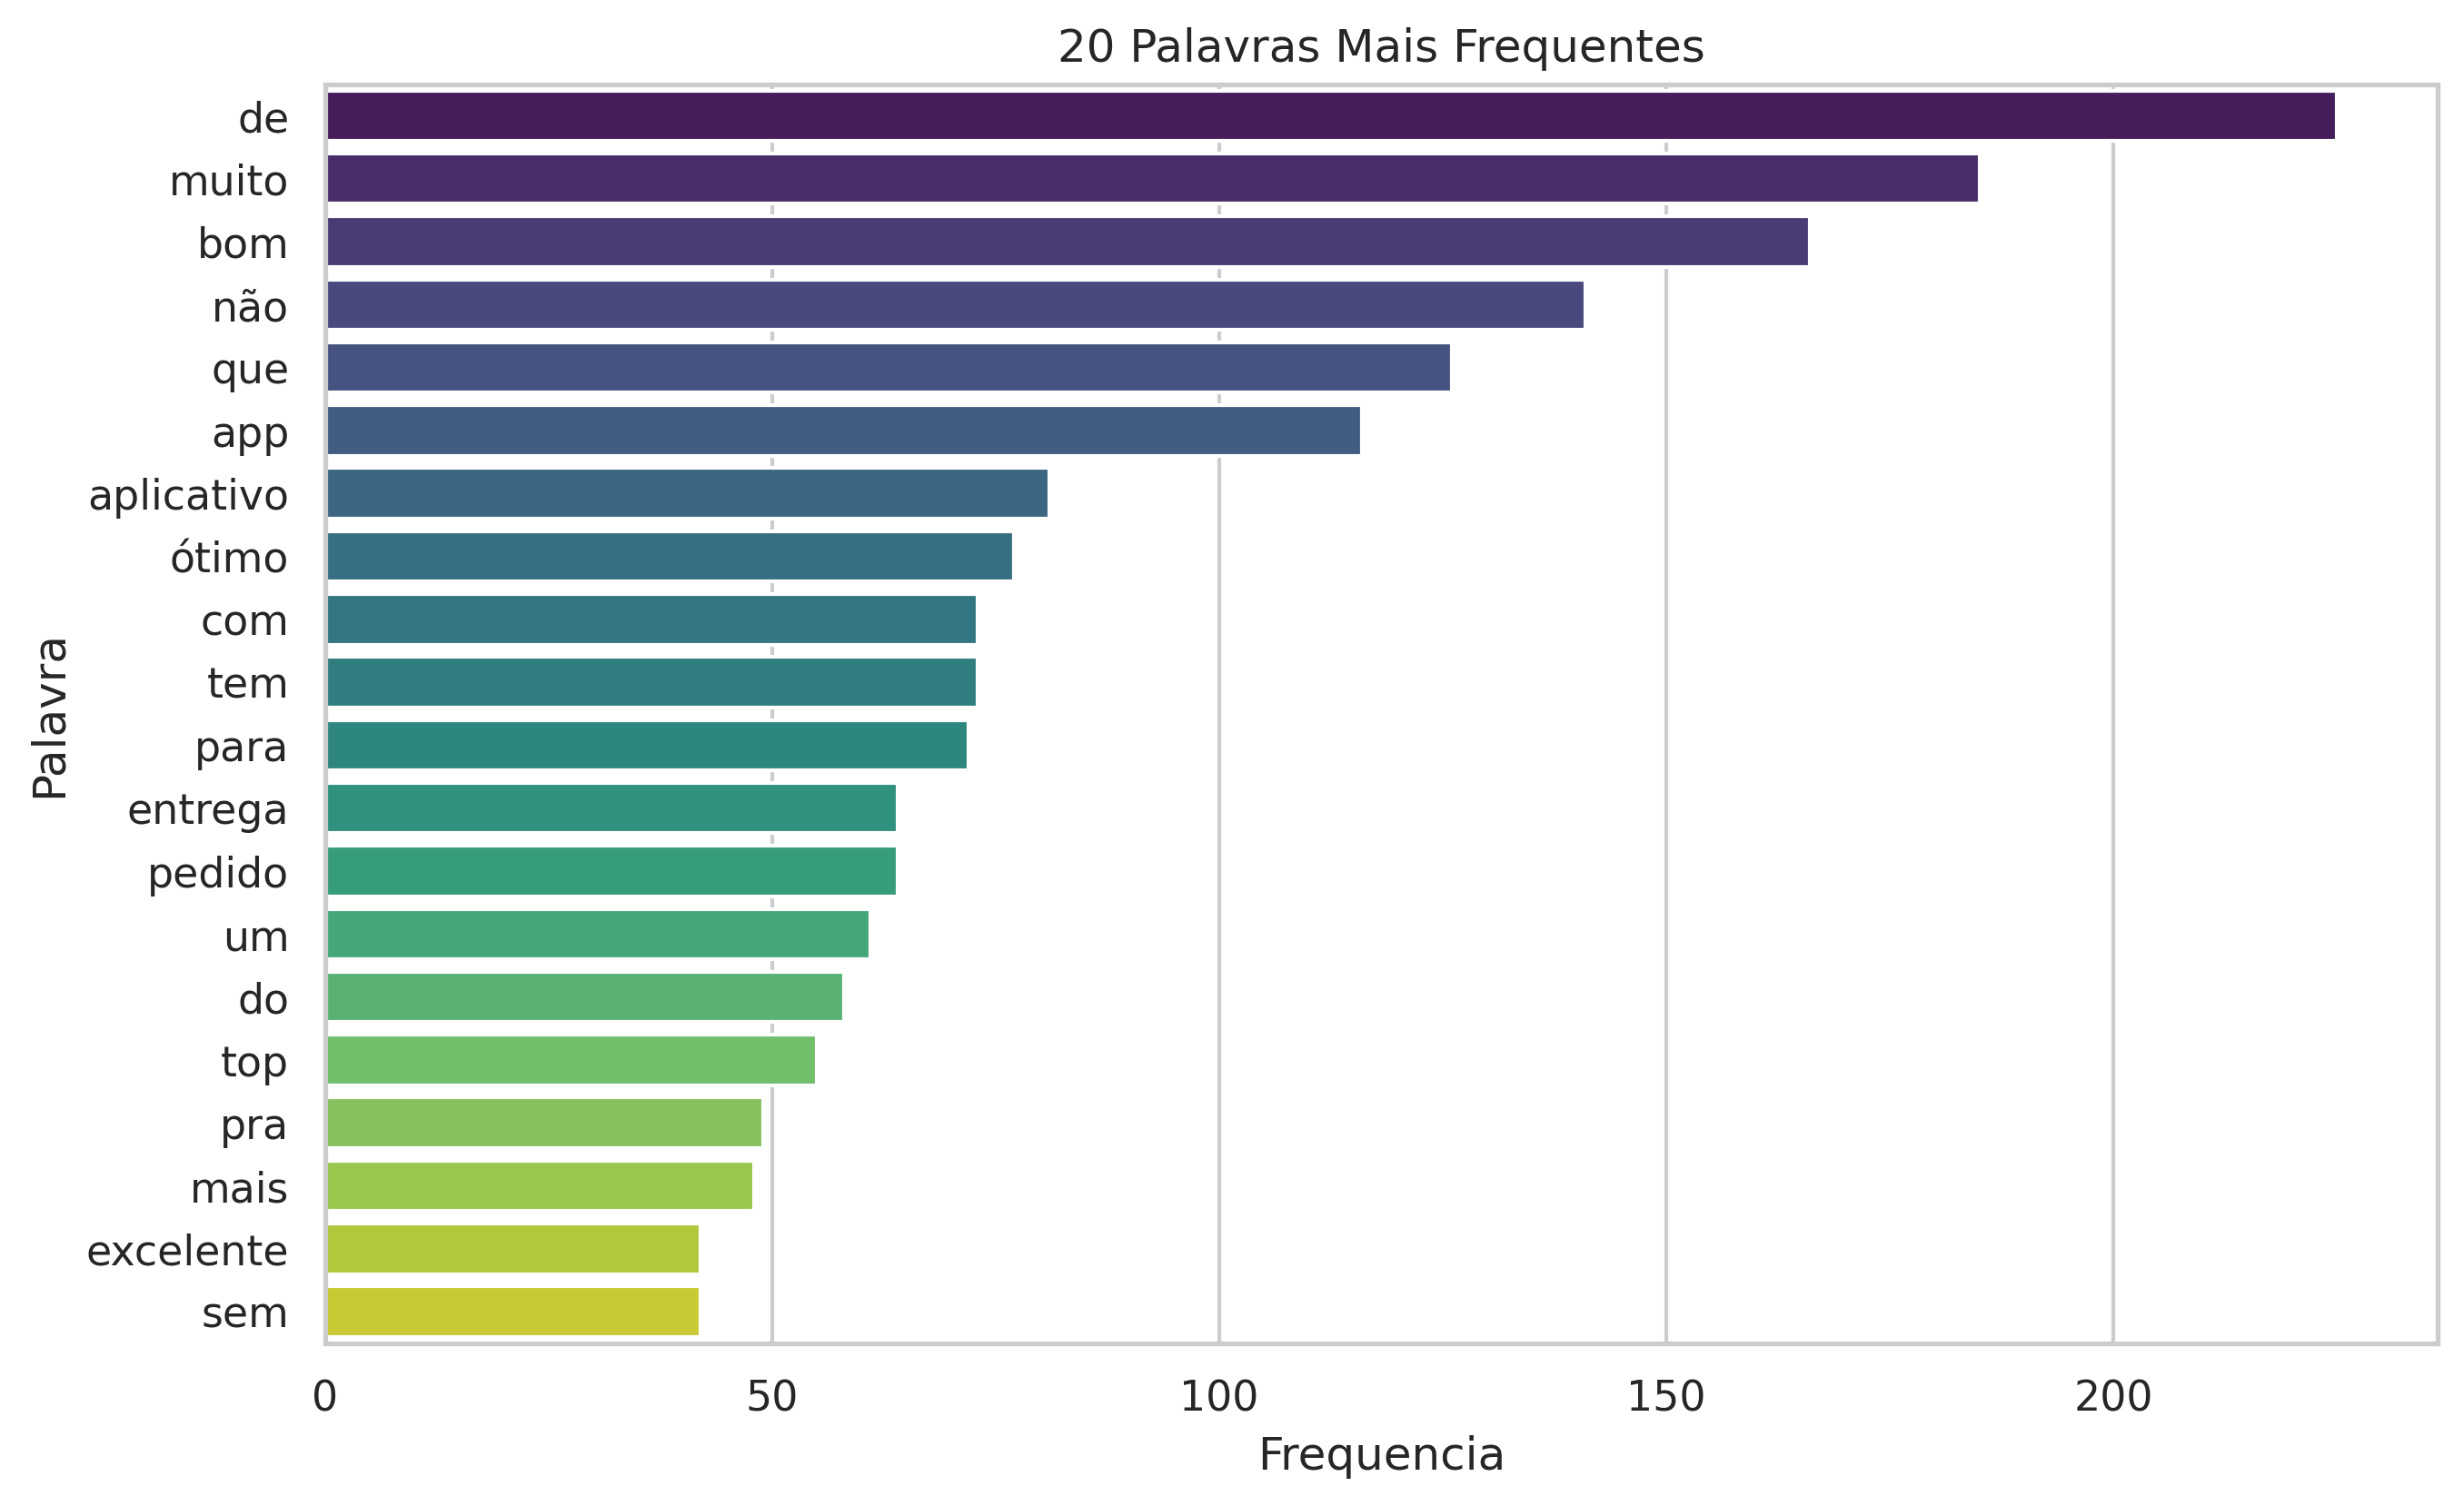

In [ ]:
# vetorizador
vectorizer = CountVectorizer()

# transforma a coluna de texto limpo em uma matriz de contagem
X_contagem = vectorizer.fit_transform(df_final['comentario'])

# soma a freq de cada palavra em todas as linhas
soma_palavras = X_contagem.sum(axis=0)

# lista de palavras por frequência
frequencia = [(word, soma_palavras[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

# passa para DataFrame e ordena
df_freq = pd.DataFrame(frequencia, columns=['Palavra', 'Frequencia'])
df_freq = df_freq.sort_values(by='Frequencia', ascending=False).head(20)

# plot
plt.figure(figsize=(10,6), dpi=300)
sns.barplot(
    data=df_freq,
    x='Frequencia',
    y='Palavra',
    palette='viridis',
    hue='Palavra',
    legend=False
)
plt.title('20 Palavras Mais Frequentes')
plt.show()

In [ ]:
df_freq.head(50)

,Palavra,Frequencia
69,de,225
11,muito,185
40,bom,166
12,não,141
1,que,126
63,app,116
62,aplicativo,81
256,ótimo,77
29,com,73
49,tem,73


In [ ]:
# stopwords do domínio de delivery
palavras_dominio = ['app', 'aplicativo', 'pra', 'pro', 'vc', 'tá', 'q']
stop_words_portugues.extend(palavras_dominio)

print(f"Total de stopwords na lista: {len(stop_words_portugues)}")

Total de stopwords na lista: 242


In [ ]:
# remove_stopwords=True
df_filtro['sem_stopwords'] = df_filtro['comentario'].apply(
    lambda x: " ".join(preprocess_text(x, remove_stopwords=True, apply_stemming=False))
)

# remove_stopwords=False
df_filtro['com_stopwords'] = df_filtro['comentario'].apply(
    lambda x: " ".join(preprocess_text(x, remove_stopwords=False, apply_stemming=False))
)

# criação de dois datasets, para análise posterior
df_sem_stopwords = df_filtro[['aplicativo', 'sem_stopwords', 'nota']].copy()
df_sem_stopwords.rename(columns={'sem_stopwords': 'comentario'}, inplace=True)
df_com_stopwords = df_filtro[['aplicativo', 'com_stopwords', 'nota']].copy()
df_com_stopwords.rename(columns={'com_stopwords': 'comentario'}, inplace=True)

# passagem para CSV
df_sem_stopwords.to_csv('delivery_reviews_sem_stopwords.csv', index=False, encoding='utf-8')
df_com_stopwords.to_csv('delivery_reviews_com_stopwords.csv', index=False, encoding='utf-8')

In [ ]:
print(f" Sem Stopwords ")
print(f"---------------")
display(df_sem_stopwords.head(3))

print(f"\n Com Stopwords ")
print(f"---------------")
display(df_com_stopwords.head(3))

 Sem Stopwords 
---------------


,aplicativo,comentario,nota
0,iFood,inventaram ifood vou restaurantes,5
1,iFood,ifood vida amo,5
2,iFood,existindo devolução dinheiro compra item falta...,2



 Com Stopwords 
---------------


,aplicativo,comentario,nota
0,iFood,depois que inventaram ifood nem vou pra restau...,5
1,iFood,ifood vida amo muito,5
2,iFood,não está existindo devolução do dinheiro quand...,2


In [ ]:
# df_com_stopwords = pd.read_csv('delivery_reviews_com_stopwords.csv')
# df_sem_stopwords = pd.read_csv('delivery_reviews_sem_stopwords.csv')

In [ ]:
total_palavras_com = df_com_stopwords['comentario'].apply(lambda x: len(str(x).split())).sum()
total_palavras_sem = df_sem_stopwords['comentario'].apply(lambda x: len(str(x).split())).sum()

palavras_removidas = total_palavras_com - total_palavras_sem

print(f"Total de palavras na base com stopwords: {total_palavras_com}")
print(f"Total de palavras na base sem stopwords: {total_palavras_sem}")
print(f"Palavras Removidas: {palavras_removidas}")

Total de palavras na base com stopwords: 5514
Total de palavras na base sem stopwords: 3456
Palavras Removidas: 2058


## **Representação Textual: BERTimbau**

Para o **TF-IDF** (_Term Frequency-Inverse Document Frequency_) e **Bag of Words** (baselines) será usado o _dataset_ sem _stopwords_. Para **BERTimbau** (_Embeddings_), será usado o  _dataset_ com _stopwords_ e sem _stopwords_  para comparação.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_sem_stopwords = pd.read_csv('delivery_reviews_sem_stopwords.csv')
df_com_stopwords = pd.read_csv('delivery_reviews_com_stopwords.csv')

Inicialmente, será gerado apenas a representação matricial para o BERTimbau, enquanto na etapa de classificação, seguindo o exemplo do ```scikit```, [Sample pipeline for text feature extraction and evaluation: Pipeline with hyperparameter tuning](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_text_feature_extraction.html#pipeline-with-hyperparameter-tuning), será aplicado um ```Pipeline``` para os outros métodos com otimização automática de hiperparâmetros.

In [ ]:
from sentence_transformers import SentenceTransformer

# modelo pré-treinado BERTimbau multilingual
modelo_bert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# transformação do dataset com stopwords
textos_para_bert_com_stop = df_com_stopwords['comentario'].fillna('').tolist()
X_embeddings_com_stop = modelo_bert.encode(textos_para_bert_com_stop, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
print(f"\nDimensões da Matriz de Embeddings: {X_embeddings_com_stop.shape}")


Dimensões da Matriz de Embeddings: (342, 384)


In [ ]:
# transformação do dataset sem stopwords
textos_para_bert_sem_stop = df_sem_stopwords['comentario'].fillna('').tolist()
X_embeddings_sem_stop = modelo_bert.encode(textos_para_bert_sem_stop, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
print(f"\nDimensões da Matriz de Embeddings: {X_embeddings_sem_stop.shape}")


Dimensões da Matriz de Embeddings: (342, 384)


## **Agrupamento dos Comentários**

Uso de K-Means (com $k=3$, $k=5$ e $k=6$) e agrupamento hierárquico, método Ward (também com $k=3$, $k=5$ e $k=6$).

> ### **Uso de IA (_Google Gemini 3.1 Pro_): Escolha para Agrupamento**
>
> Nessa etapa **(Agrupamento Não Supervisionado)**, optou por utilizar a matriz de embeddings gerada pela família BERT/Transformers alimentada com o dataset **contendo stopwords**.
>
> #### _Por que manter Stopwords_
> A arquitetura *Transformer* baseia-se no mecanismo de **Atenção Bidirecional (Self-Attention)**. O modelo não analisa termos de forma estática, mas sim o contexto global da frase. Nesse paradigma, as *stopwords* funcionam como a estrutura sintática essencial. Remover termos como "não", "mas", "de" ou "para" destrói a coesão semântica.
>
> #### _Agrupamento_
> Ao utilizar os embeddings densos do BERT com o contexto preservado, o algoritmo de clustering (K-Means) calcula distâncias geométricas baseadas na similaridade semântica (intenção) e não na repetição de palavras. Avaliações com sinônimos são mapeadas para regiões próximas, gerando clusters mais coesos e interpretáveis para a rotulação.

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

In [ ]:
# df_sem_stopwords = pd.read_csv('delivery_reviews_sem_stopwords.csv')
# df_com_stopwords = pd.read_csv('delivery_reviews_com_stopwords.csv')

In [ ]:
#usaremos os embeddings do BERT com stopwords
X_cluster = X_embeddings_com_stop

In [ ]:
configuracoes = [
    {"metodo": "K-Means", "k": 3, "modelo": KMeans(n_clusters=3, random_state=42, n_init=10)}, #inclusão de k=3, para observação das métricas
    {"metodo": "K-Means", "k": 5, "modelo": KMeans(n_clusters=5, random_state=42, n_init=10)},
    {"metodo": "K-Means", "k": 6, "modelo": KMeans(n_clusters=6, random_state=42, n_init=10)},
    {"metodo": "Hierárquico (Ward)", "k": 3, "modelo": AgglomerativeClustering(n_clusters=3, linkage='ward')}, #inclusão de k=3, para observação das métricas
    {"metodo": "Hierárquico (Ward)", "k": 5, "modelo": AgglomerativeClustering(n_clusters=5, linkage='ward')},
    {"metodo": "Hierárquico (Ward)", "k": 6, "modelo": AgglomerativeClustering(n_clusters=6, linkage='ward')}
]

resultados_metricas = []
dicionario_labels = {}

for conf in configuracoes:
    nome_config = f"{conf['metodo']} (k={conf['k']})"
    modelo = conf['modelo']

    #geração dos rótulos (clusters)
    labels = modelo.fit_predict(X_cluster)
    dicionario_labels[nome_config] = labels

    #métricas
    score_sil = silhouette_score(X_cluster, labels)
    score_db = davies_bouldin_score(X_cluster, labels)
    score_ch = calinski_harabasz_score(X_cluster, labels)

    resultados_metricas.append({
        'Configuração': nome_config,
        'Silhouette (maior é melhor)': score_sil,
        'Davies-Bouldin (menor é melhor)': score_db,
        'Calinski-Harabasz (maior é melhor)': score_ch
    })

df_metricas_cluster = pd.DataFrame(resultados_metricas)
df_metricas_cluster = df_metricas_cluster.sort_values(by='Silhouette (maior é melhor)', ascending=False).reset_index(drop=True)

display(df_metricas_cluster)

,Configuração,Silhouette (maior é melhor),Davies-Bouldin (menor é melhor),Calinski-Harabasz (maior é melhor)
0,K-Means (k=3),0.091203,2.520676,35.486145
1,Hierárquico (Ward) (k=3),0.079034,2.835680,28.578531
2,K-Means (k=5),0.076221,2.893622,26.135355
3,K-Means (k=6),0.075892,2.983139,22.773722
4,Hierárquico (Ward) (k=5),0.061636,2.976100,22.239737
5,Hierárquico (Ward) (k=6),0.047704,3.123524,19.746786


---
 **Silhouette Score**: mede o quão semelhante é um ponto de dado ao seu próprio cluster em comparação com outros clusters. Considera dois aspectos:
  - _Coesão_ $(a(i))$: Quão perto um ponto de dado está de outros pontos em seu próprio cluster.
  - _Separação_ $(b(i))$: Quão longe um ponto de dado está dos pontos no cluster vizinho mais próximo.

  Para um único ponto $i$, temos

  $$ s(i) = \frac{b(i)-a(i)}{\max\{a(i), b(i) \}}, \quad -1\leq s(i) \leq 1$$

  Se $s(i) = +1$, então o ponto está longe de ser de outros clusters e bem combinado para o seu próprio cluster. Se $s(i) = 0$, então o ponto é equidistante entre dois clusters. Se $s(i) = -1$, o ponto está mais próximo de outro cluster do que o seu próprio.

---

**Davies-Bouldin index (DBI)**: é uma métrica de validação de cluster que avalia a qualidade do agrupamento medindo a semelhança média entre clusters, onde a similaridade é definida como a razão de dispersão dentro do cluster para a separação entre clusters. Desenvolvido por Davies e Bouldin em 1979, este índice foi projetado para identificar clusters compactos e bem separados.

É calculado da seguinte forma:

$$\text{DBI}(k) = \frac{1}{k}\sum_{i=1}^{k} \left\{\frac{\delta_i+\delta_j}{d_{ij}} \right\}, \quad 0\leq\text{DBI}(k) < +\infty $$
onde

- $k$ é o número de clusters;
- $\delta_i$ é a dispersão dentro do cluster para cluster $i$;
- $d_{ij}$ é distância entre os centros de cluster $i$ e $j$.

A dispersão dentro do cluster para cluster $i$ é calculada como:

$$\delta_i = \left[\frac{1}{n_i}\sum_{x\in C_i}\sum_{j=1}^{p}|x_{ij}-c_{ij}|^{u} \right]^{1/u} $$

onde:

- $n_i$ é o número de pontos no cluster $i$;
- $C_i$ é o conjunto de pontos no cluster $i$;
- $c_{ij}$ é o $j$-ésimo componente do centroide do cluster $i$;
- $u$ é um parâmetro (normalmente $u=2$, dando o desvio padrão).

A distância entre os centroides de cluster $i$ e $j$ é calculada como:

$$d_{ij} = \left[\sum_{l=1}^{p}|c_{il} - c_{jl}|^{\nu} \right]^{1/\nu} $$

onde:
- $\nu$ é um parâmetro (tipicamente $\nu=2$, dando a distância euclidiana);
- $c_{il}$ e $c_{jl}$ são os componentes $l$-ésimos dos centroides $i$ e $j$, respectivamente.

Valores baixos de $\text{DB}$ indcam melhor grupamento com clusters compactos e bem separados. Valores mais altos sugerem que os clusters estão mais espalhados internamente ou muito próximos um do outro.

O número ideal de clusters corresponde ao valor mínimo do índice de Davies-Bouldin. Isso ocorre quando os clusters são internamente compactos (pequenos valores de $\delta_i$) e bem separados entre si (grandes valores de $d_{ij}$).


---

**Calinski-Harabasz Index (CHI)**: avalia a qualidade do agrupamento comparando a dispersão entre-cluster com a dispersão dentro do cluster. O número ótimo de clusters corresponde ao valor máximo do índice de Calinski-Harabasz. O princípio fundamental por trás deste método é que o bom agrupamento deve maximizar a separação entre os clusters, minimizando a variância dentro dos clusters. Clusters que são bem separados entre si e internamente coesos produzirão valores de índice mais altos.

É calculado da seguinte forma:

$$\text{CHI}(k) = \dfrac{\dfrac{\text{BCSS}}{(k-1)}}{\dfrac{\text{WCSS}}{(n-k)}} = \frac{\text{BCSS}}{\text{WCSS}}\cdot \frac{(n-k)}{(k-1)}$$

onde:

- $k$ é o número de clusters;
- $n$ é o número total de pontos de dados;
- $\text{BCSS}$ é a soma entre-cluster de quadrados;
- $\text{WCSS}$ é a soma dentro-cluster de quadrados.

A soma entre-cluster de quadrados mede a dispersão entre os centroides de cluster:

$$\text{BCSS} = \sum_{i=1}^{k} n_i \| c_i - \overline{c}\|^2$$

onde:

- $n_i$ é o número de pontos no cluster $i$;
- $c_i$ é o centroide no cluster $i$;
- $\overline{c}$ é o centroide geral de todos os pontos de dados;
- $\|c_i - \overline{c}\|^2$ é a distância quadrática de Euclides entre o cluster centroide $i$ e o centroide geral.

A soma dentro do cluster de quadrados mede a dispersão dentro de clusters:

$$\text{WCSS}= \sum_{i=1}^{k}\sum_{x\in C_i} \| x-c_i\|^2 $$

onde:

- $C_i$ é o conjunto de pontos no cluster $i$;
- $x$ representa cada ponto de dados individual no cluster $i$;
- $c_i$ é o centroide do cluster $i$;
- $\overline{c}$ é o centroide geral de todos os pontos de dados;
- $\|x-c_i\|^2$ é a distância quadrada euclidiana entre o ponto $x$ e seu cluster centroide.


**Observação sobre os resultados**: Como analisado pela etapa de EDA, no geral, os comentários se dividem em dois extremos, ou comentários com grandes elogios ou com muitas críticas (uma vez que, normalmente, as pessoas avaliam mais em situações extremas). Nesse sentido, o agrupamento em 3 classes se mostrou melhor do que para classes maiores. _Devido à restrição do trabalho_, no entanto, será usado $k=5$, que é o número mínimo de classes exigido (e possui uma avaliação melhor do que para $k$ maior).

O K-Means, nesse caso, teve um melhor resultado sobre o Ward (método de Variância Mínima).

**Referências**:
- [Agglomerative Hierarchical Clustering using Ward Linkage](https://jbhender.github.io/Stats506/F18/GP/Group10.html).
- [Data Mining: Distances between Clustering, Hierarchical
Clustering](https://www.stat.cmu.edu/~cshalizi/350/lectures/08/lecture-08.pdf).
- [Selecting the optimal number of clusters](https://www.graphpad.com/guides/prism/latest/statistics/stat_clustering_optimal_cluster_number.htm).

Seguindo o exemplo do ```scikit```: [Selecting the number of clusters with silhouette analysis on KMeans clustering](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) é possível fazer um _silhouette plot_ para observar o comportamento das classes.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


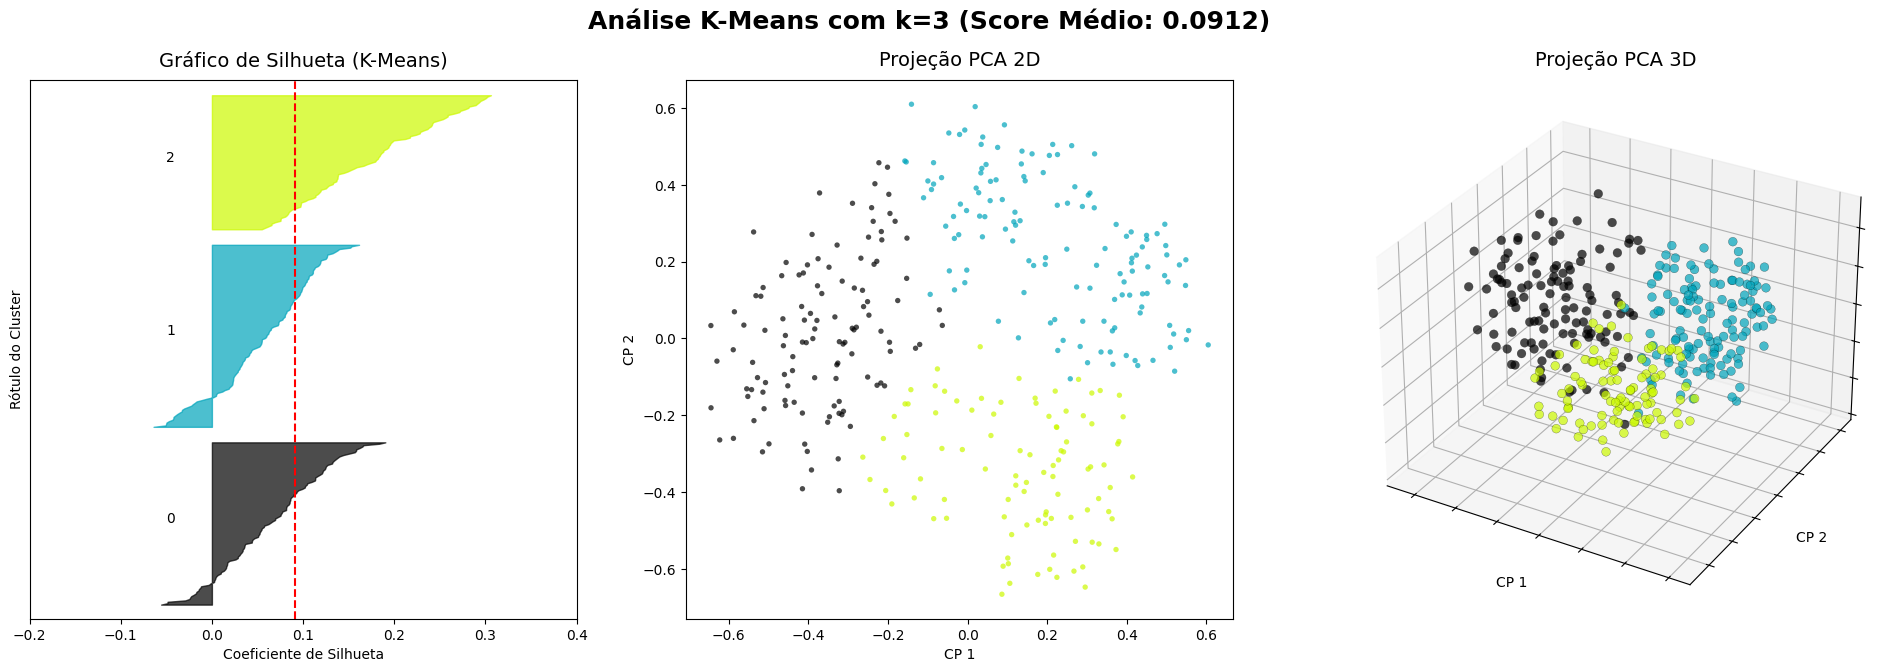

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


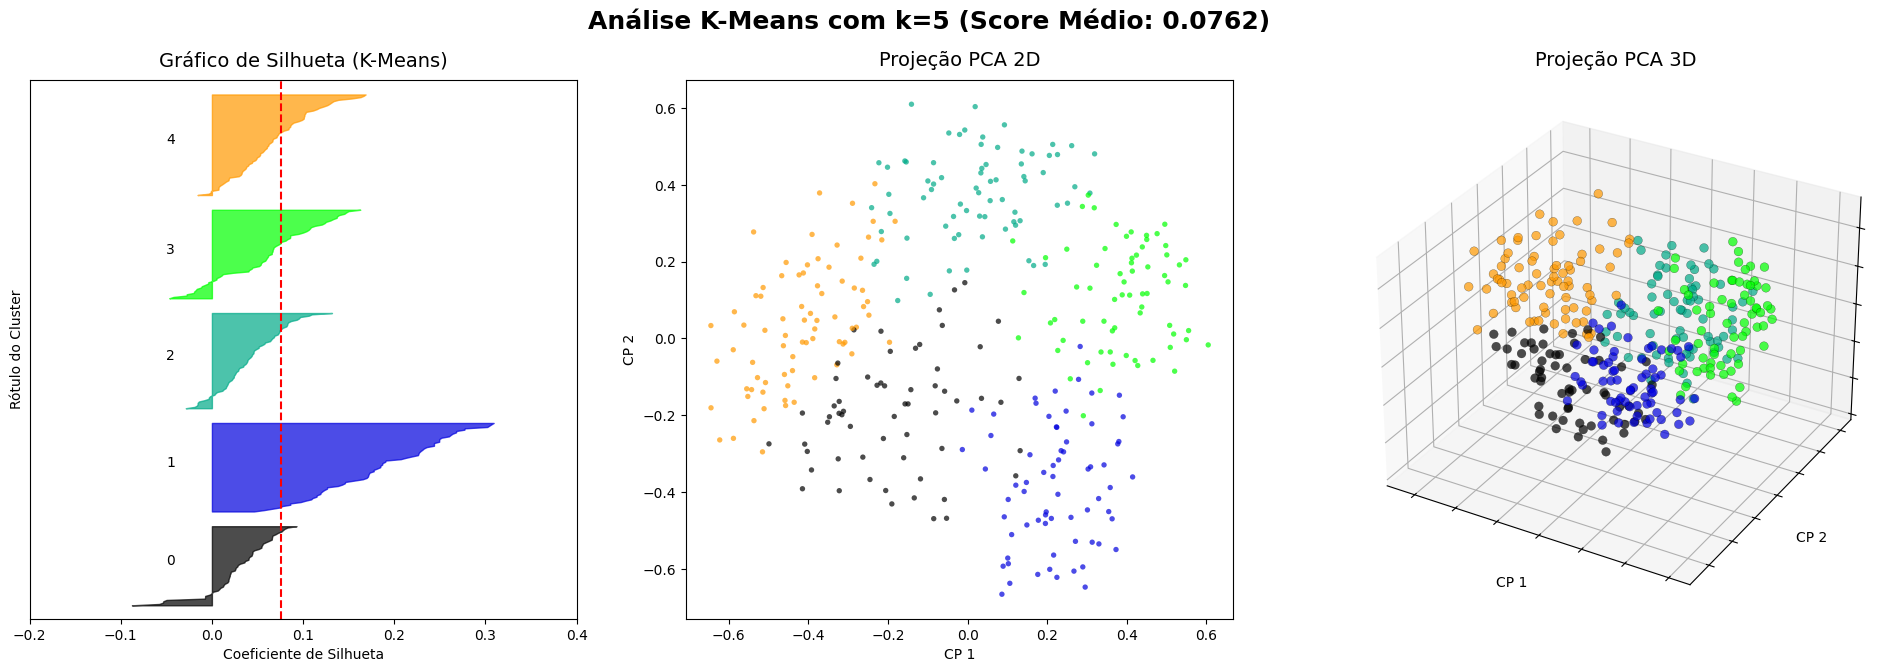

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


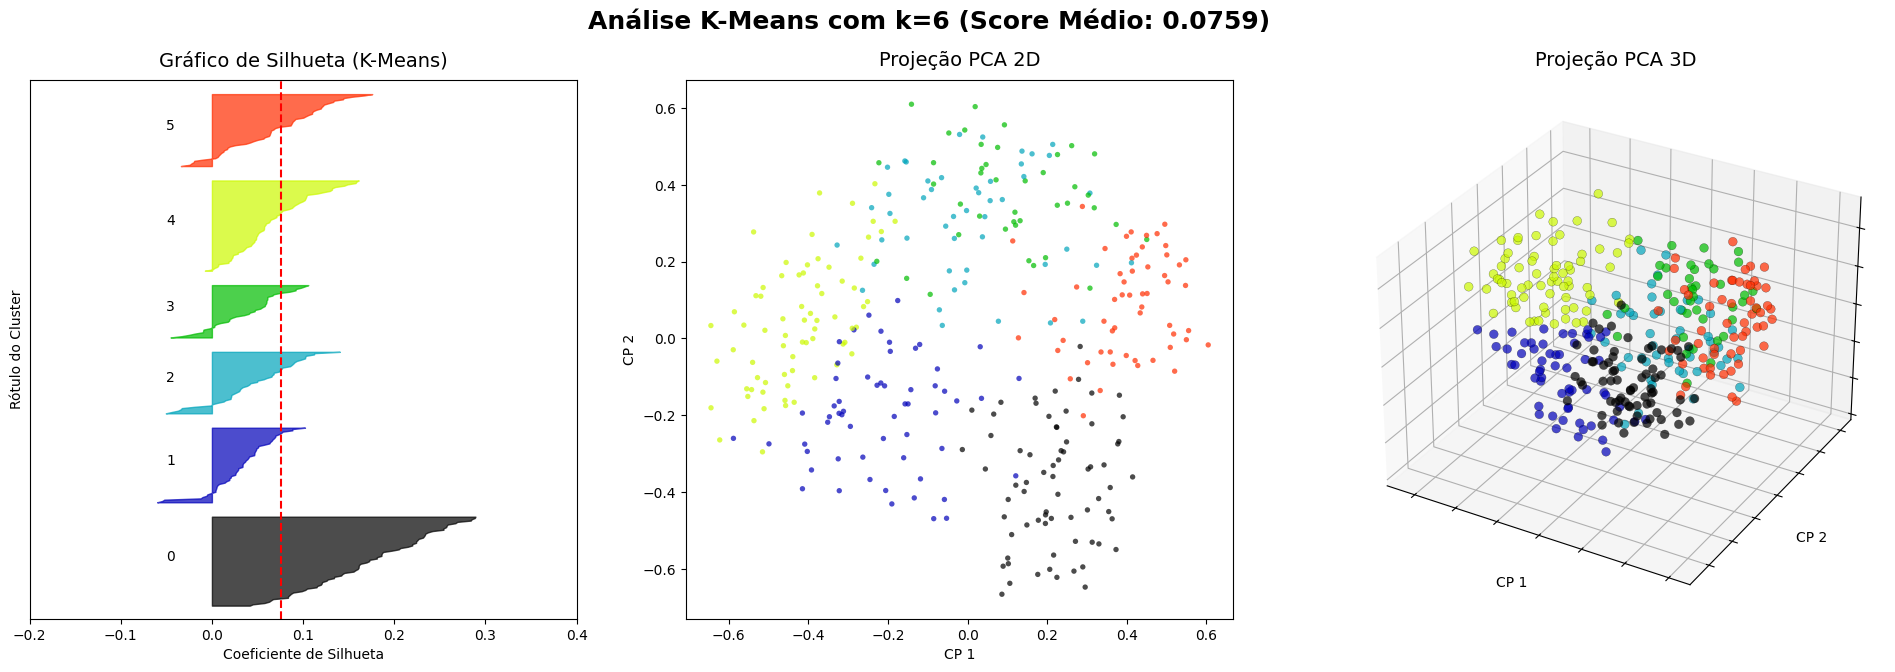

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


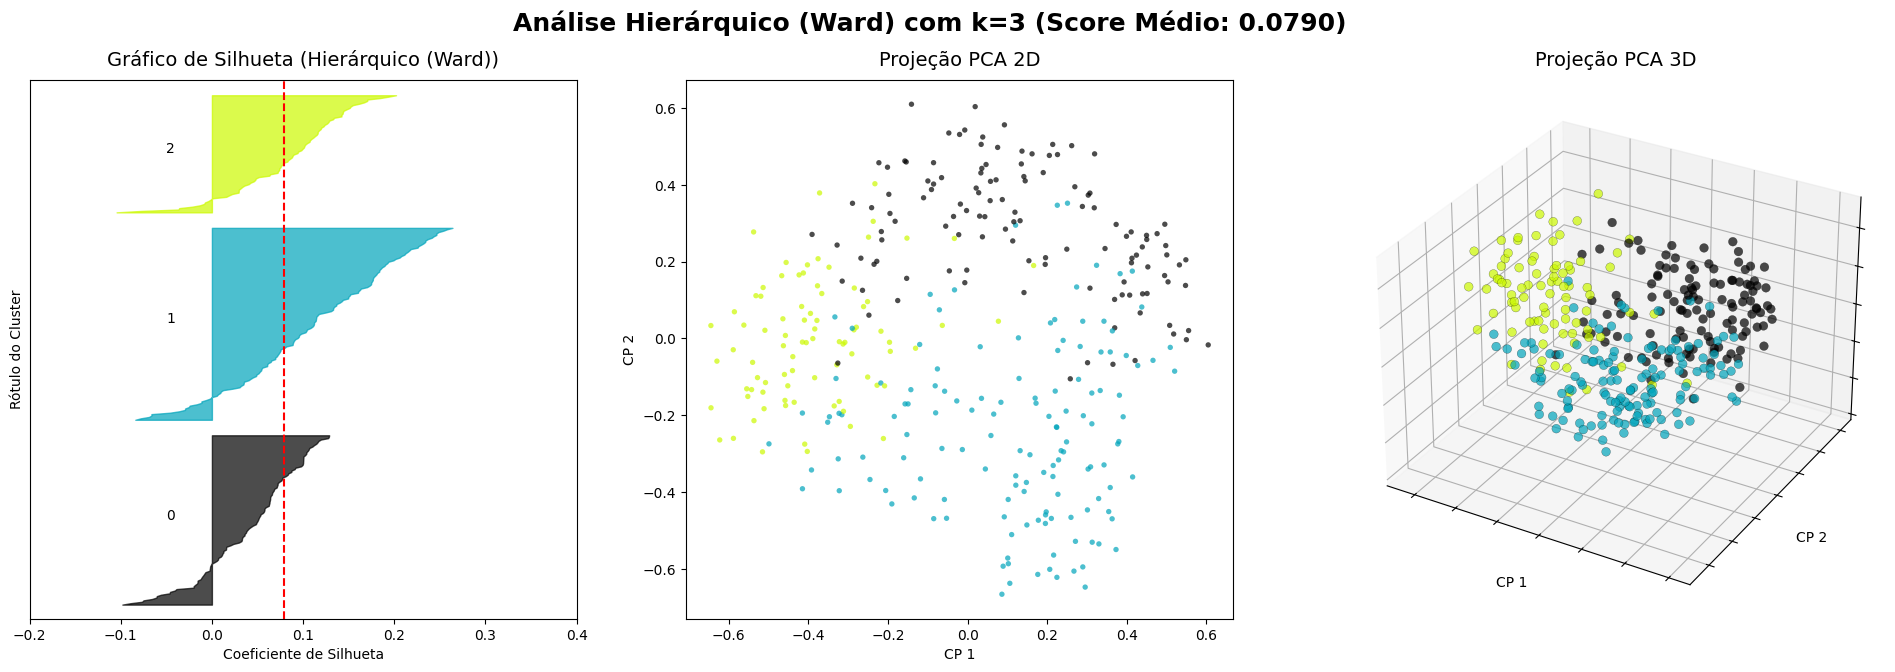

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


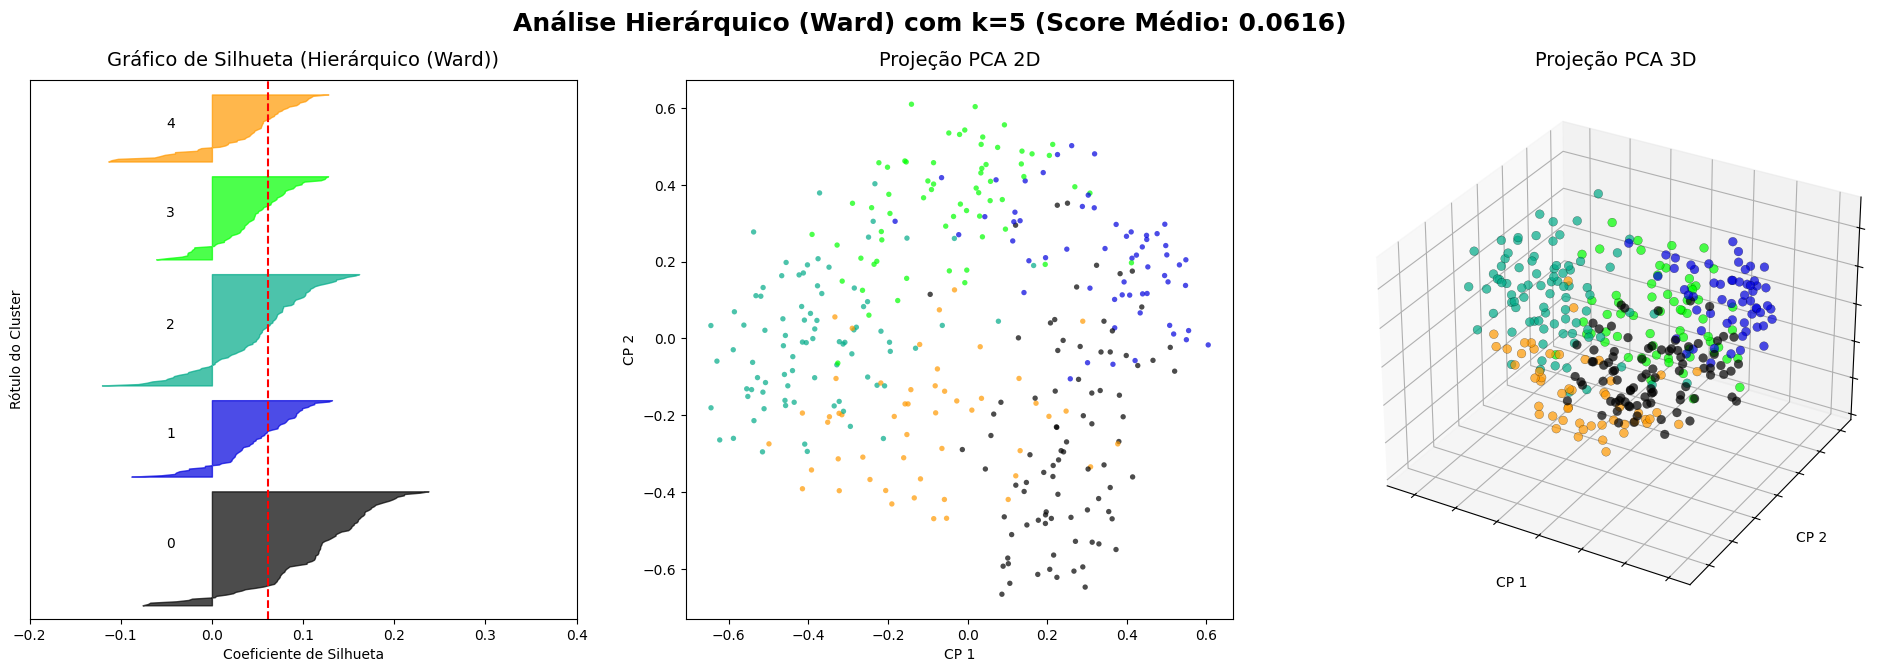

/tmp/ipykernel_1795/2013210911.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


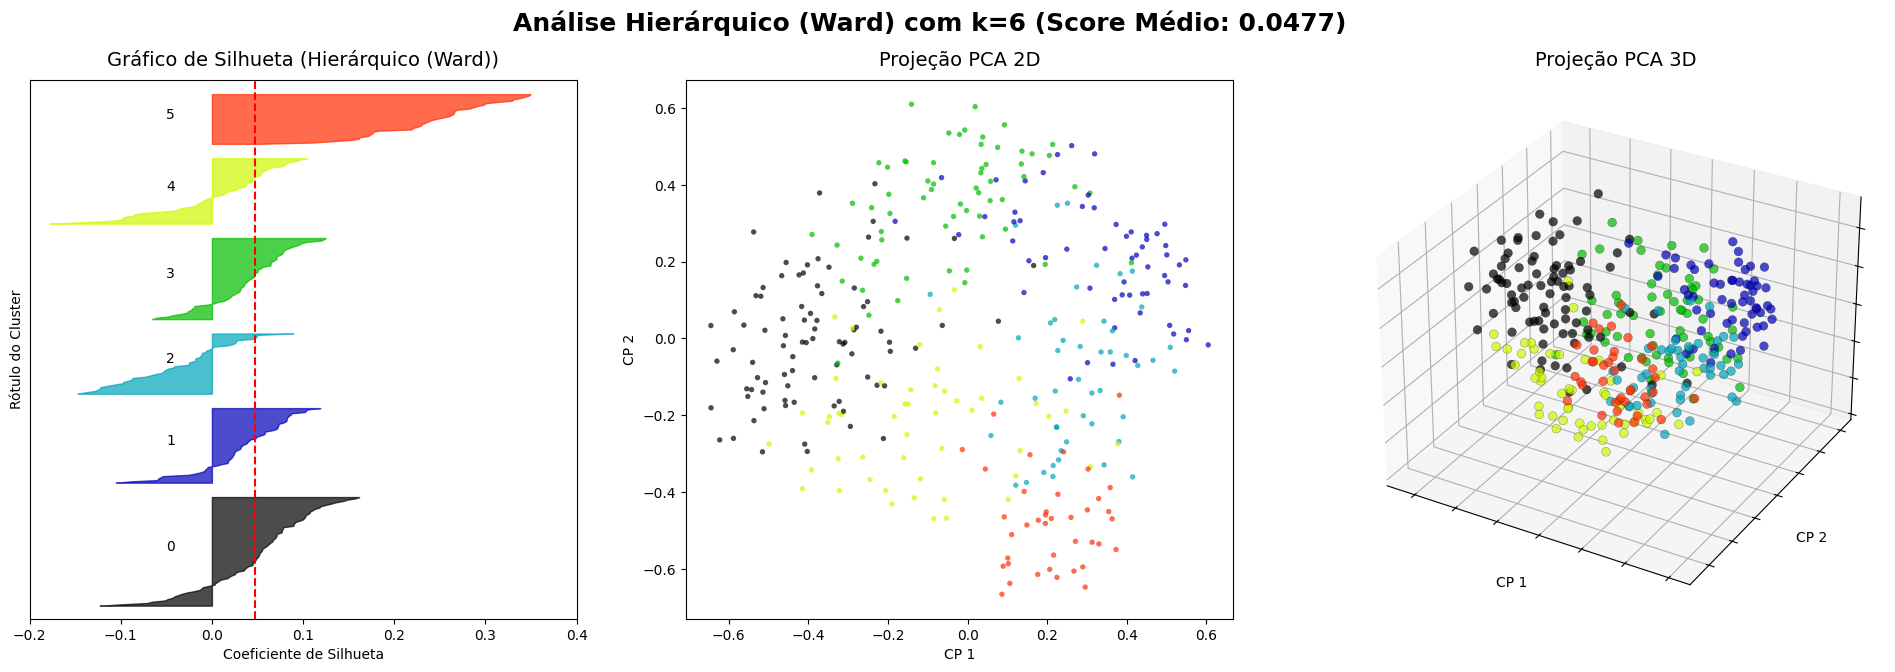

In [ ]:
# USO DE IA (Google Gemini 3.1 Pro): usado para gerar os gráficos abaixo de maneira correta

pca_3d = PCA(n_components=3, random_state=40)
X_pca_3d = pca_3d.fit_transform(X_cluster)

valores_k = [3, 5, 6]
metodos = ['K-Means', 'Hierárquico (Ward)']

for metodo in metodos:
    for n_clusters in valores_k:
        if metodo == 'K-Means':
            clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        else:
            clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')

        cluster_labels = clusterer.fit_predict(X_cluster)

        #métricas
        silhouette_avg = silhouette_score(X_cluster, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_cluster, cluster_labels)

        fig = plt.figure(figsize=(24, 7))

        #lâminas de Silhueta
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.set_xlim([-0.2, 0.4])
        ax1.set_ylim([0, len(X_cluster) + (n_clusters + 1) * 10])

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i
            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax1.set_title(f"Gráfico de Silhueta ({metodo})", fontsize=14, pad=10)
        ax1.set_xlabel("Coeficiente de Silhueta")
        ax1.set_ylabel("Rótulo do Cluster")
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

        # scatter Plot PCA (2D)
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.scatter(
            X_pca_3d[:, 0], X_pca_3d[:, 1], marker=".", s=60, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )
        ax2.set_title("Projeção PCA 2D", fontsize=14, pad=10)
        ax2.set_xlabel("CP 1")
        ax2.set_ylabel("CP 2")

        # scatter Plot PCA (3D)
        ax3 = fig.add_subplot(1, 3, 3, projection='3d')
        ax3.scatter(
            X_pca_3d[:, 0],
            X_pca_3d[:, 1],
            X_pca_3d[:, 2],
            c=colors,
            alpha=0.7,
            s=40,
            edgecolor='k',
            linewidth=0.2
        )
        ax3.set_title("Projeção PCA 3D", fontsize=14, pad=10)
        ax3.set_xlabel('CP 1')
        ax3.set_ylabel('CP 2')
        ax3.set_zlabel('CP 3')

        ax3.set_xticklabels([])
        ax3.set_yticklabels([])
        ax3.set_zticklabels([])

        plt.suptitle(
            f"Análise {metodo} com k={n_clusters} (Score Médio: {silhouette_avg:.4f})",
            fontsize=18,
            fontweight="bold",
        )
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

No _silhouette plot_, a altura representa o total de comentários que caíram naquele cluster e o comprimento o quão separados os pontos estão. Se cruzar a marca do zero para a esquerda, significa que o algoritmo agrupou aquele comentário no Cluster A, mas ele, na verdade, era mais parecido com os textos do Cluster B (o valor 0 indica que está bem próximo da fronteira de decisão).

Amostras de cada classe:

In [ ]:
#considerando K-means com k=5 (o que obteve as melhores métricas)
melhor_configuracao = "K-Means (k=5)"

# adiciona os rótulos do melhor modelo ao dataframe original
df_com_stopwords['cluster_id'] = dicionario_labels[melhor_configuracao]

num_clusters_final = df_com_stopwords['cluster_id'].nunique()

for cluster in range(num_clusters_final):
    comentarios_cluster = df_com_stopwords[df_com_stopwords['cluster_id'] == cluster]['comentario']
    total_comentarios = len(comentarios_cluster)

    #cabeçalho
    print(f" Cluster {cluster} | Total de comentários: {total_comentarios}")
    #amostra
    amostras = comentarios_cluster.sample(min(20, total_comentarios), random_state=42).values

    for amostra in amostras:
        print(f" - {amostra}")
    print("-" * 75)
    print()

 Cluster 0 | Total de comentários: 60
 - muito prático resolve necessidade recomendo
 - fácil prático contém muitas promoções muito boa
 - fácil de fazer pedidos com grandes descontos
 - localização em tempo real muito útil
 - muito bom muita promoção comida gostosa
 - prático rápido muito bom ainda acompanho entregasuper gostei👍
 - muito bom porém agora tá adicionando taxas adicionais
 - intuitivo rápido não há poluição visual quando estamos escolhendo
 - sempre encontro bons restaurantes melhor preço justo
 - preços iguais aos da loja física
 - muito bem elaboradoobjetivo rápido
 - rápido na entrega pessoas educadas
 - simples prático funciona bem demais
 - muito fácil prático de fazer os pedidos so gostaria que na minha região tivesse mais entregas com rastreamento até porque bom saber onde está meu pedido
 - muito bom uso muito recomendo
 - amo ifood de inteira responsabilidade com cliente
 - promoções todos os dias muito bom ifood
 - boas opções bons preços
 - melhor aplicativo de

**Análise de cada Cluster**:
- _Cluster 0_: No geral, comentários positivos, longos e mais genéricos sobre os aplicativos.
- _Cluster 1_: Reclamações mais extremas, sobre demora, extorno do valor pago, descontos e cupons, e avaliações do entregador.
- _Cluster 2_: No geral, comentários bons sobre a usabilidade do aplicativo e variabilidade de opções.
- _Cluster 3_: No geral, comentários ruins sobre a usabilidade do aplicativo e variabilidade de opções.
- _Cluster 4_: No geral, comentários positivos e curtos.

## **Rotulagem dos Comentários e Avaliação**

In [ ]:
# rótulos

#df_com_stopwords['cluster_id'] = dicionario_labels[melhor_configuracao]

mapa_classes = {
    0: "Elogio - Variedade e Praticidade",
    1: "Reclamação - Financeiro, Logística e Atendimento",
    2: "Elogio - Usabilidade do App",
    3: "Reclamação - Bugs, Suporte e Usabilidade do App",
    4: "Elogio - Elogios Gerais e Qualidade de Entregas"
}

# coluna final (y) no dataset com stopwords
df_com_stopwords['classe_alvo'] = df_com_stopwords['cluster_id'].map(mapa_classes)

# variável alvo no dataset sem stopwords
df_sem_stopwords['classe_alvo'] = df_com_stopwords['classe_alvo']

# verificação (verifica se tem valores nulos ou tamanhos distintos)
if (df_com_stopwords['classe_alvo'].isnull().sum() == 0) and (len(df_com_stopwords) == len(df_sem_stopwords)):
    print("Rótulos mapeados corretamente.")
    print("\nDistribuição final das classes (Variável y):")
    display(df_com_stopwords['classe_alvo'].value_counts())
else:
    print("Inconsistência no tamanho dos datasets ou valores nulos.")

Rótulos mapeados corretamente.

Distribuição final das classes (Variável y):


,count
classe_alvo,
Elogio - Elogios Gerais e Qualidade de Entregas,76
Elogio - Usabilidade do App,72
"Reclamação - Financeiro, Logística e Atendimento",67
"Reclamação - Bugs, Suporte e Usabilidade do App",67
Elogio - Variedade e Praticidade,60


Seguindo o exemplo [Clustering text documents using k-means: Top terms per cluster](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html#top-terms-per-cluster), usamos o código abaixo para ver as principais palavras em cada cluster.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# CÓDIGO OBTIDO VIA IA (Google Gemini 3.1 Pro)

print("10 Principais Termos por Cluster (Baseado em c-TF-IDF)\n")

textos_por_cluster = df_sem_stopwords.groupby('classe_alvo')['comentario'].apply(lambda x: ' '.join(x.dropna())).reset_index()
tfidf_extrator = TfidfVectorizer(max_df=1.0, min_df=1)
matriz_tfidf_clusters = tfidf_extrator.fit_transform(textos_por_cluster['comentario'])
termos = tfidf_extrator.get_feature_names_out()

for i in range(len(textos_por_cluster)):
    nome_da_classe = textos_por_cluster['classe_alvo'].iloc[i]
    print(f"[{nome_da_classe}]: ", end="")

    # pega a linha correspondente ao cluster e ordena os índices do maior para o menor peso
    indices_ordenados = matriz_tfidf_clusters[i].toarray().argsort()[0][::-1]

    # imprime os 10 primeiros
    for ind in indices_ordenados[:10]:
        print(f"{termos[ind]} ", end="")
    print("\n")

10 Principais Termos por Cluster (Baseado em c-TF-IDF)

[Elogio - Elogios Gerais e Qualidade de Entregas]: bom rápido gelada chegou super sempre entrega melhor demais top 

[Elogio - Usabilidade do App]: pedido opção dinheiro entrega endereço loja ter cupom ifood volta 

[Elogio - Variedade e Praticidade]: fácil bom prático entrega bem opções preços rápida simples recomendo 

[Reclamação - Bugs, Suporte e Usabilidade do App]: pedido péssimo entrega loja problema entrar bom nada opção nao 

[Reclamação - Financeiro, Logística e Atendimento]: ótimo bom melhor usar excelente fácil mundo fazer super opções 



Abaixo, vamos pegar os comentários rotulados e analisar a corretudo.

In [ ]:
df_com_stopwords[['comentario', 'nota', 'classe_alvo']].to_excel('amostra_revisao.xlsx', index=True) # exportação para excel

## **Validação das Rotulações e Análise**

In [ ]:
# Mapeamento dos índices dos comentários com classificação incorreta

# Está [Elogio - Elogios Gerais e Qualidade de Entregas] era pra ser [Elogio - Usabilidade do App]
idx_EGQE_to_UA = [192, 193, 209]

# Está [Elogio - Elogios Gerais e Qualidade de Entregas] era pra ser [Elogio - Variedade e Praticidade]
idx_EGQE_to_VP = [44, 103, 105, 110, 168, 177, 189, 235, 266]

# Está [Elogio - Elogios Gerais e Qualidade de Entregas] era pra ser [Reclamação - Bugs, Suporte e Usabilidade do App]
idx_EGQE_to_BSU = [18, 111, 258, 282, 295, 315]

# Está [Elogio - Elogios Gerais e Qualidade de Entregas] era pra ser [Reclamação - Financeiro, Logística e Atendimento]
idx_EGQE_to_FLA = [207, 225, 270]

# Está [Elogio - Usabilidade do App] era pra ser [Reclamação - Financeiro, Logística e Atendimento]
idx_UA_to_FLA = [2, 60, 68, 73, 79, 90, 94, 112, 116, 135, 137, 147, 164, 165, 175, 180, 194, 195, 203, 214, 215, 238, 240, 242, 257, 273, 274, 287, 288, 290, 308, 310, 318]

# Está [Elogio - Usabilidade do App] era pra ser [Reclamação - Bugs, Suporte e Usabilidade do App]
idx_UA_to_BSU = [3, 5, 10, 16, 17, 23, 26, 50, 64, 84, 88, 89, 118, 144, 154, 155, 158, 183, 187, 222, 233, 250, 259, 281, 292, 309, 311, 325, 329, 331, 333]

# Está [Reclamação - Financeiro, Logística e Atendimento] era pra ser [Elogio - Usabilidade do App]
idx_FLA_to_UA = [7, 22, 33, 38, 54, 69, 77, 132, 134, 146, 150, 156, 162, 198, 199, 212, 230, 236, 244, 245, 284, 332]

# Está [Reclamação - Financeiro, Logística e Atendimento] era pra ser [Elogio - Variedade e Praticidade]
idx_FLA_to_VP = [28, 29, 32, 46, 63, 67, 102, 106, 107, 108, 136, 140, 142, 143, 169, 170, 173, 174, 182, 185, 252, 279, 291, 294, 298, 300, 316, 320, 322, 324, 338]

# Está [Reclamação - Financeiro, Logística e Atendimento] era pra ser [Reclamação - Bugs, Suporte e Usabilidade do App]
idx_FLA_to_BSU = [243, 276, 277]

# Está [Reclamação - Financeiro, Logística e Atendimento] era pra ser [Elogio - Elogios Gerais e Qualidade de Entregas]
idx_FLA_to_EGQE = [45, 48, 51, 83, 96, 97, 115, 159, 161, 163, 172, 191, 196, 197, 301, 305, 317]

# Está [Reclamação - Bugs, Suporte e Usabilidade do App] era pra ser [Elogio - Usabilidade do App]
idx_BSU_to_UA = [41, 121, 123]

# Está [Reclamação - Bugs, Suporte e Usabilidade do App] era para ser [Reclamação - Financeiro, Logística e Atendimento]
idx_BSU_to_FLA = [205, 326]

# Está [Reclamação - Bugs, Suporte e Usabilidade do App] era para ser [Elogio - Elogios Gerais e Qualidade de Entregas]
idx_BSU_to_EGQE = [100, 119]

# Está [Reclamação - Bugs, Suporte e Usabilidade do App] era para ser [Elogio - Variedade e Praticidade]
idx_BSU_to_VP = [128, 160]

# Está [Elogio - Variedade e Praticidade] era pra ser [Elogio - Elogios Gerais e Qualidade de Entregas]
idx_VP_to_EGQE = [49, 71, 211, 272, 299, 336, 337]

# Está [Elogio - Variedade e Praticidade] era pra ser [Elogio - Usabilidade do App]
idx_VP_to_UA = [120, 122, 130, 131, 166, 171, 184, 186]

# Está [Elogio - Variedade e Praticidade] era pra ser [Reclamação - Bugs, Suporte e Usabilidade do App]
idx_VP_to_BSU = [124]

# Está [Elogio - Variedade e Praticidade] era pra ser [Reclamação - Financeiro, Logística e Atendimento]
idx_VP_to_FLA = [138, 141, 204, 260]

In [ ]:
# aplicação das correções nos rótulos dos datasets

correcoes = {
    "Elogio - Usabilidade do App": idx_EGQE_to_UA + idx_FLA_to_UA + idx_BSU_to_UA + idx_VP_to_UA,
    "Elogio - Variedade e Praticidade": idx_EGQE_to_VP + idx_FLA_to_VP + idx_BSU_to_VP,
    "Reclamação - Bugs, Suporte e Usabilidade do App": idx_EGQE_to_BSU + idx_UA_to_BSU + idx_FLA_to_BSU + idx_VP_to_BSU,
    "Reclamação - Financeiro, Logística e Atendimento": idx_EGQE_to_FLA + idx_UA_to_FLA + idx_VP_to_FLA + idx_BSU_to_FLA,
    "Elogio - Elogios Gerais e Qualidade de Entregas": idx_FLA_to_EGQE + idx_BSU_to_EGQE + idx_VP_to_EGQE
}


indices_alterados = []

# dataset com stopwords
for classe_correta, lista_de_indices in correcoes.items():
    if lista_de_indices:
        df_com_stopwords.loc[lista_de_indices, 'classe_alvo'] = classe_correta
        indices_alterados.extend(lista_de_indices)

#dataset sem stopwords
df_sem_stopwords['classe_alvo'] = df_com_stopwords['classe_alvo']

In [ ]:
# amostra dos comentários rotulados incorretamente

amostra_problemas = df_com_stopwords.loc[indices_alterados, ['comentario', 'classe_modelo', 'classe_alvo']].sample(10, random_state=42)

for index, row in amostra_problemas.iterrows():
    print(f"--> Índice: {index}")
    print(f"    Texto: '{row['comentario']}'")
    print(f"    Rótulo original (K-Means): [{row['classe_modelo']}]")
    print(f"    Rótulo corrigido: [{row['classe_alvo']}]\n")
    print("-"*80)

--> Índice: 336
    Texto: 'top como fazer pra cadastrar loja'
    Rótulo original (K-Means): [Elogio - Variedade e Praticidade]
    Rótulo corrigido: [Elogio - Elogios Gerais e Qualidade de Entregas]

--------------------------------------------------------------------------------
--> Índice: 18
    Texto: 'valores falsos um lanche no biggs frango duplo nao reais igual tá falando na promoção de reais por reais isso enganação'
    Rótulo original (K-Means): [Elogio - Elogios Gerais e Qualidade de Entregas]
    Rótulo corrigido: [Reclamação - Bugs, Suporte e Usabilidade do App]

--------------------------------------------------------------------------------
--> Índice: 136
    Texto: 'ótimo para encontrar variedades de comida bebidassobremesa num único lugar sem sair de casa melhor qualquer hora'
    Rótulo original (K-Means): [Elogio - Variedade e Praticidade]
    Rótulo corrigido: [Elogio - Variedade e Praticidade]

--------------------------------------------------------------------

In [ ]:
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns

In [ ]:
print(" Observação estatística das rotulações incorretas \n")

# coluna com a previsão original do modelo
df_com_stopwords['classe_modelo'] = df_com_stopwords['cluster_id'].map(mapa_classes)

# comentários que foram corrigidos
df_erros = df_com_stopwords[df_com_stopwords['classe_modelo'] !=df_com_stopwords['classe_alvo']]

total_comentarios=len(df_com_stopwords)
total_erros =len(df_erros)
taxa_erro =(total_erros/total_comentarios)*100

print(f"Total de comentários na base: {total_comentarios}")
print(f"Total de comentários reclassificados: {total_erros}")
print(f"Taxa de divergência (Modelo vs. Validação): {taxa_erro:.2f}%\n")

 Observação estatística das rotulações incorretas 

Total de comentários na base: 342
Total de comentários reclassificados: 167
Taxa de divergência (Modelo vs. Validação): 48.83%



In [ ]:
# classe com maior erro
erros_origem = df_erros['classe_modelo'].value_counts().reset_index()
erros_origem.columns = ['Classe incorreta (modelo)', 'Qtd de Erros']
print("Classes com maior índice de erro do algoritmo:")
display(erros_origem)

# clases corretas (de destino)
erros_destino = df_erros['classe_alvo'].value_counts().reset_index()
erros_destino.columns = ['Classe correta (validação)', 'Qtd de Correções Recebidas']
print("\n Classes que mais receberam comentários após a revisão:")
display(erros_destino)

Classes com maior índice de erro do algoritmo:


,Classe incorreta (modelo),Qtd de Erros
0,Elogio - Usabilidade do App,62
1,"Reclamação - Financeiro, Logística e Atendimento",60
2,Elogio - Elogios Gerais e Qualidade de Entregas,19
3,Elogio - Variedade e Praticidade,19
4,"Reclamação - Bugs, Suporte e Usabilidade do App",7



 Classes que mais receberam comentários após a revisão:


,Classe correta (validação),Qtd de Correções Recebidas
0,"Reclamação - Financeiro, Logística e Atendimento",42
1,"Reclamação - Bugs, Suporte e Usabilidade do App",40
2,Elogio - Variedade e Praticidade,36
3,Elogio - Usabilidade do App,29
4,Elogio - Elogios Gerais e Qualidade de Entregas,20


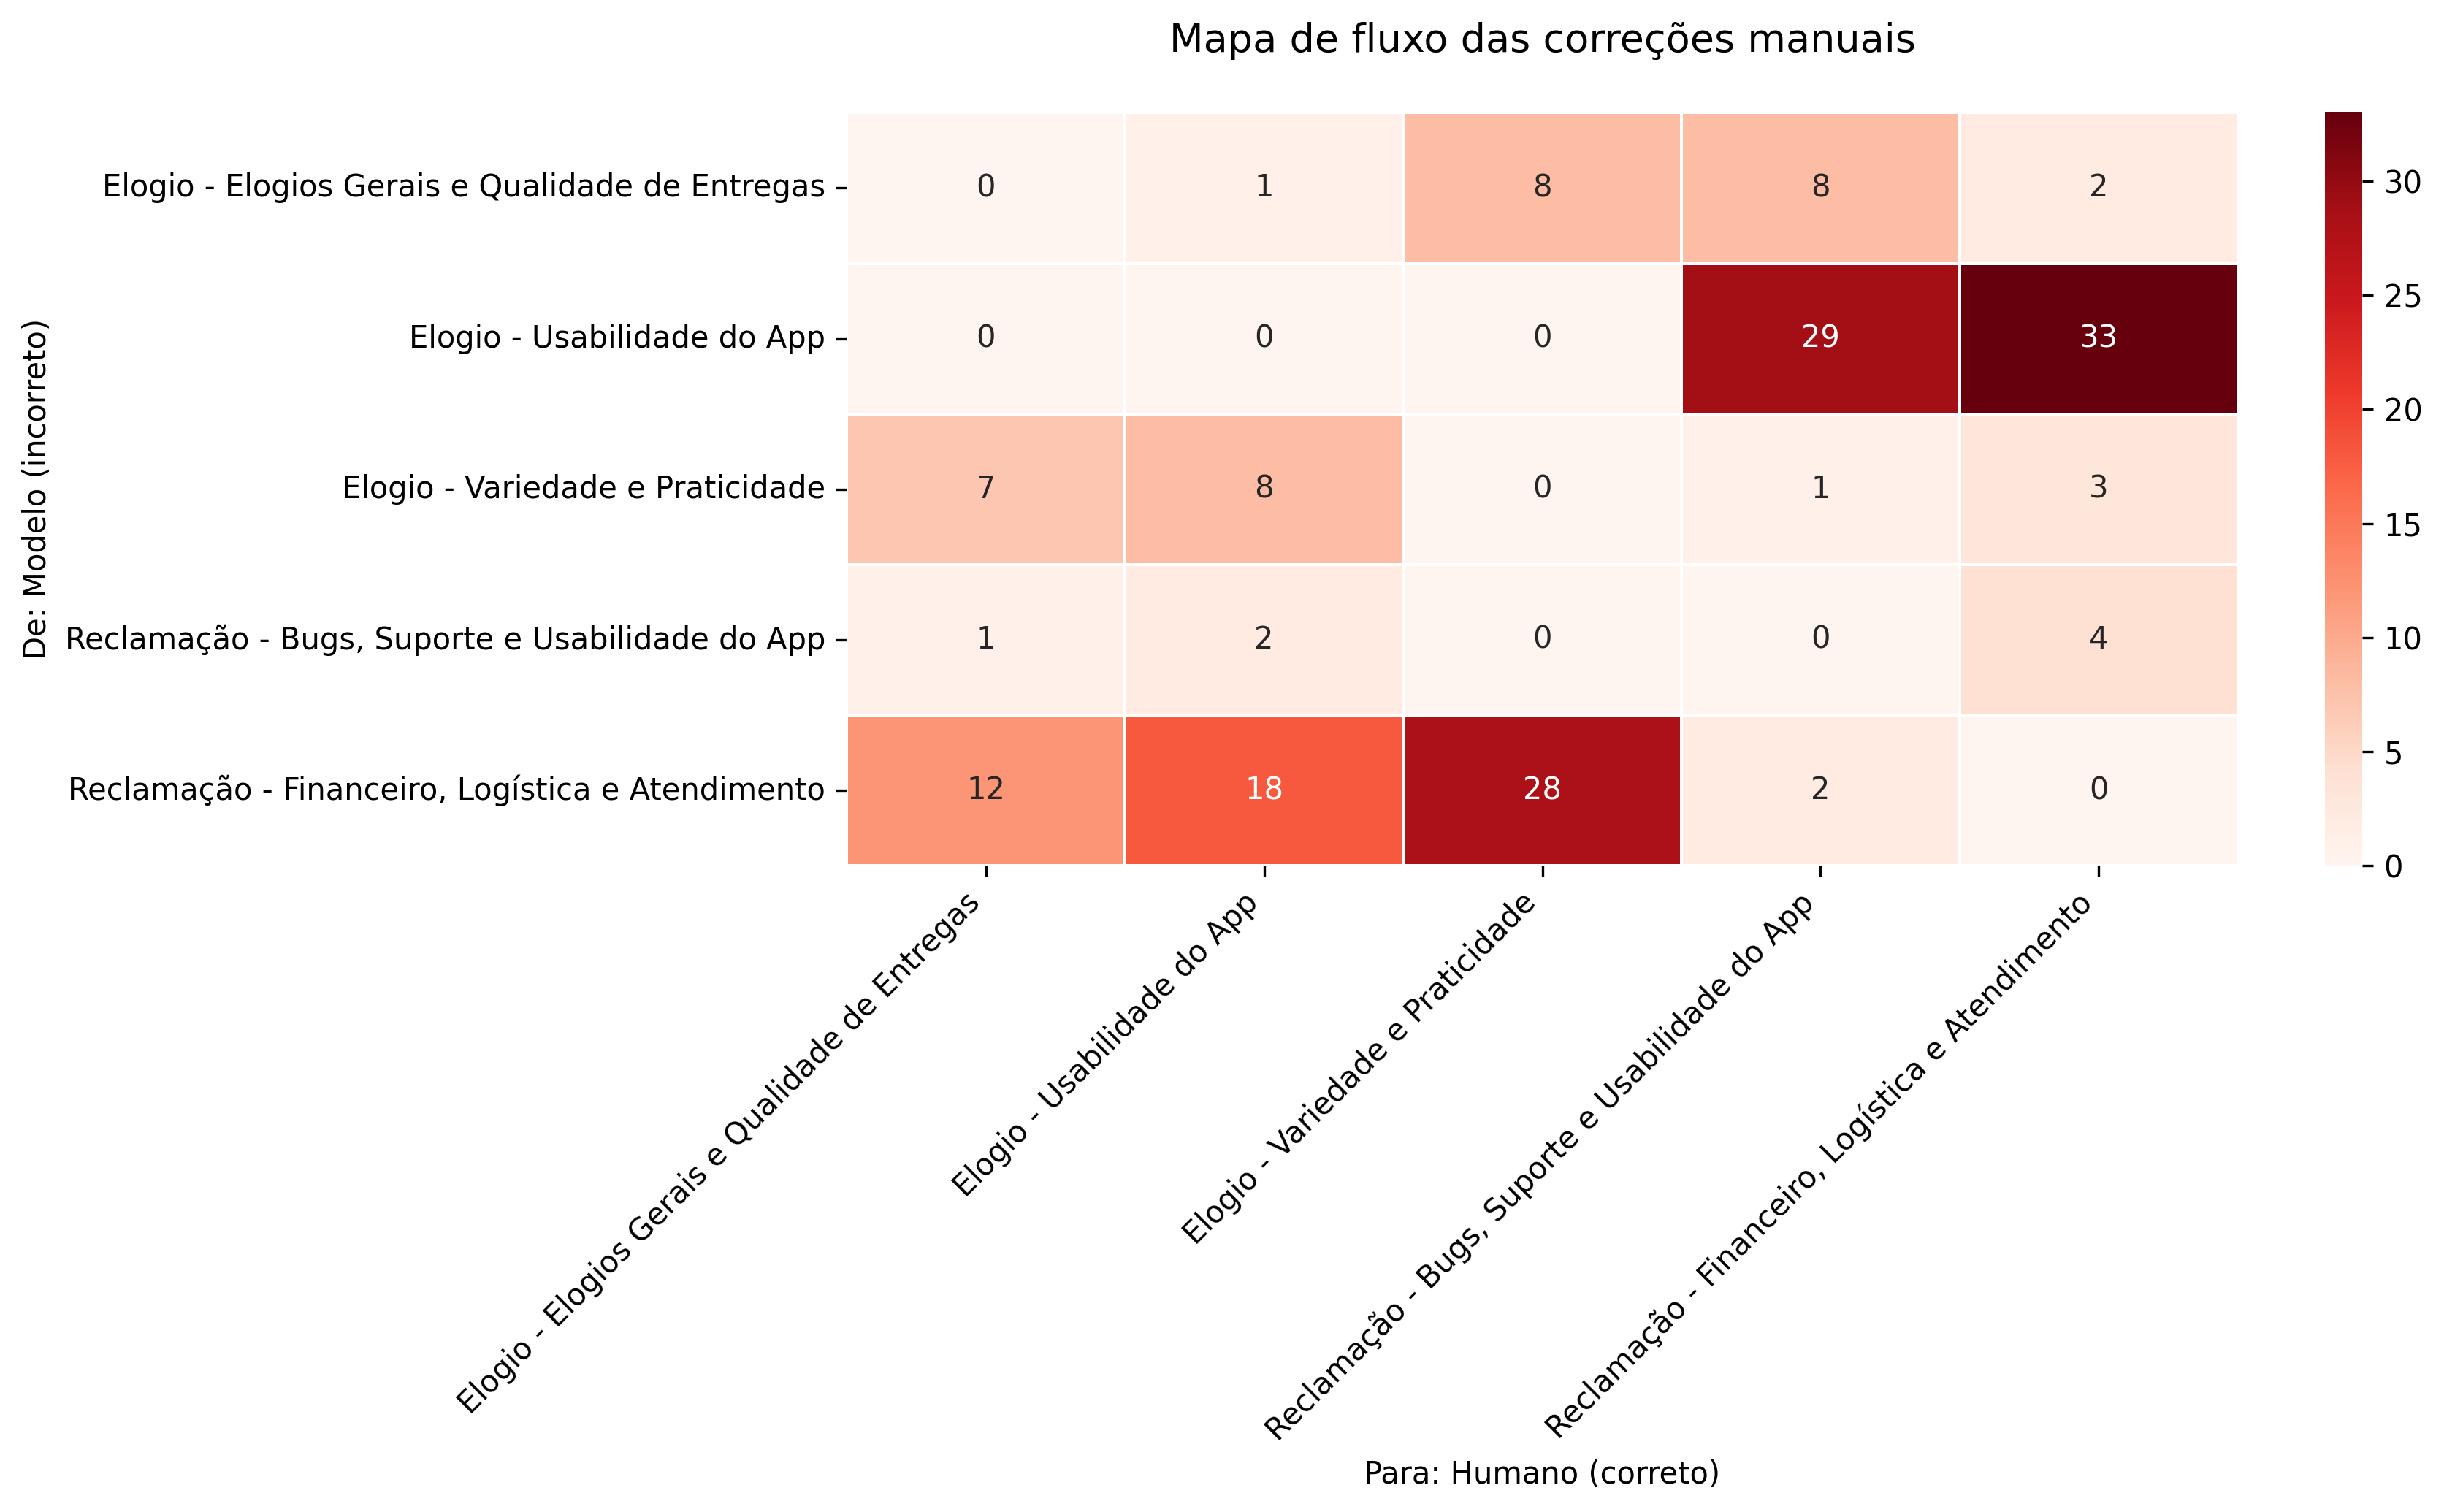

In [ ]:
# mapa de calor

# quantas vezes a classe X virou a classe Y
matriz_correcoes = pd.crosstab(
    df_erros['classe_modelo'],
    df_erros['classe_alvo'],
    rownames=['De: Modelo (incorreto)'],
    colnames=['Para: Humano (correto)']
)

plt.figure(figsize=(12,7),dpi=300)
sns.heatmap(matriz_correcoes, annot=True,cmap='Reds',fmt='d',linewidths=.5)
plt.title('Mapa de fluxo das correções manuais', fontsize=13, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
distribuicao_final = df_com_stopwords['classe_alvo'].value_counts().reset_index()
distribuicao_final.columns = ['Classe Final','Total de Comentários']

#add uma coluna de porcentagem
total_geral = len(df_com_stopwords)
distribuicao_final['porcentagem (%)'] = (distribuicao_final['Total de Comentários']/total_geral*100).round(2)
display(distribuicao_final)

,Classe Final,Total de Comentários,porcentagem (%)
0,"Reclamação - Bugs, Suporte e Usabilidade do App",100,29.24
1,Elogio - Variedade e Praticidade,77,22.51
2,Elogio - Elogios Gerais e Qualidade de Entregas,77,22.51
3,"Reclamação - Financeiro, Logística e Atendimento",49,14.33
4,Elogio - Usabilidade do App,39,11.40


In [ ]:
# salvamento final das bases rotuladas

arquivo_com_stop = 'delivery_reviews_com_stopwords_rotulado.csv'
arquivo_sem_stop = 'delivery_reviews_sem_stopwords_rotulado.csv'
df_com_stopwords.to_csv(arquivo_com_stop, index=False, encoding='utf-8-sig')
df_sem_stopwords.to_csv(arquivo_sem_stop, index=False, encoding='utf-8-sig')
print(f"Arquivo '{arquivo_com_stop}' salvo.")
print(f"Arquivo '{arquivo_sem_stop}' salvo.")

Arquivo 'delivery_reviews_com_stopwords_rotulado.csv' salvo.
Arquivo 'delivery_reviews_sem_stopwords_rotulado.csv' salvo.


## **Classificação**

In [ ]:
# imports

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
import torch

In [ ]:
arquivo_com_stop = 'delivery_reviews_com_stopwords_rotulado.csv'
arquivo_sem_stop = 'delivery_reviews_sem_stopwords_rotulado.csv'

# csv para dataframes
df_com_stopwords = pd.read_csv(arquivo_com_stop)
df_sem_stopwords = pd.read_csv(arquivo_sem_stop)

In [ ]:
# FUNÇÃO AUXILIAR PARA BARRA DE PROGRESSO TQDM (OBTIDO VIA IA - Google Gemini 3.1 Pro)
import contextlib
import joblib
from tqdm.auto import tqdm

@contextlib.contextmanager
def barra_tqdm(tqdm_object):
    class TqdmCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    cb_original = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = cb_original

Foram selecionados os algoritmos de **Regressão Logística**, **SVM Linear** e **Random Forest**.

### _Treinamento dos Baselines_

In [ ]:
# BASELINES
# features e target

X_text = df_sem_stopwords['comentario'].fillna('')
y = df_sem_stopwords['classe_alvo']

# estratificação 80% treino / 20% teste
idx_train, idx_test, y_train, y_test = train_test_split(
    df_sem_stopwords.index, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# texto sem stopwords (Baselines)
X_train_txt = df_sem_stopwords.loc[idx_train, 'comentario'].fillna('')
X_test_txt = df_sem_stopwords.loc[idx_test, 'comentario'].fillna('')

In [ ]:
print(f"Treino ({len(y_train)}), Teste ({len(y_test)})\n")

Treino (273), Teste (69)



In [ ]:
#---------------------------------------------
#         TREINO DOS BASELINES (TF-IDF/BoW)
#                 sem stopwords
#---------------------------------------------

pipeline_baseline = Pipeline([
    ('vetorizador', TfidfVectorizer()), # inicial apenas
    ('classificador', LogisticRegression()) # inicial apenas
])

In [ ]:
grades_baseline = {
    "Regressão Logística": (
        Pipeline([('vetorizador', TfidfVectorizer()), ('classificador', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),
        {'vetorizador': [CountVectorizer(), TfidfVectorizer()], 'vetorizador__ngram_range': [(1,1), (1,2)], 'classificador__C': [0.1, 1.0, 10.0]}
    ),
    "LinearSVC (SVM)": (
        Pipeline([('vetorizador', TfidfVectorizer()), ('classificador', LinearSVC(max_iter=2000, class_weight='balanced', random_state=42))]),
        {'vetorizador': [CountVectorizer(), TfidfVectorizer()], 'vetorizador__ngram_range': [(1,1), (1,2)], 'classificador__C': [0.1, 1.0, 10.0]}
    ),
    "Random Forest": (
        Pipeline([('vetorizador', TfidfVectorizer()), ('classificador', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))]),
        {'vetorizador': [CountVectorizer(), TfidfVectorizer()], 'vetorizador__ngram_range': [(1,1), (1,2)], 'classificador__n_estimators': [100, 200], 'classificador__max_depth': [None, 20]}
    )
}

In [ ]:
todos_os_resultados = []

for nome_alg, (pip, param) in grades_baseline.items():
    print(f" >> Otimizando {nome_alg}...")
    grid = GridSearchCV(pip, param_grid=param, cv=5, scoring='f1_macro', n_jobs=-1)
    with barra_tqdm(tqdm(desc=f"Grid {nome_alg}")):
        grid.fit(X_train_txt, y_train)

    todos_os_resultados.append({
        "Abordagem": "Baseline (sem stopwords)",
        "Algoritmo": nome_alg,
        "Melhor Vetorizador": grid.best_estimator_.named_steps['vetorizador'].__class__.__name__ + f" (ngram: {grid.best_estimator_.named_steps['vetorizador'].ngram_range})",
        "F1-Macro (Validação)": grid.best_score_,
        "Modelo Treinado": grid.best_estimator_,
        "Base de Teste": X_test_txt
    })

 >> Otimizando Regressão Logística...


Grid Regressão Logística: 0it [00:00, ?it/s]

 >> Otimizando LinearSVC (SVM)...


Grid LinearSVC (SVM): 0it [00:00, ?it/s]

 >> Otimizando Random Forest...


Grid Random Forest: 0it [00:00, ?it/s]

### _Treinamento BERTimbau_

In [ ]:
#---------------------------------------------
#               TREINO BERTimbau
#              com e sem stopwords
#---------------------------------------------

#inicializa o modelo
dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo_bert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=dispositivo)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#extração dos textos do dataset com stopwords
X_train_txt_com = df_com_stopwords.loc[idx_train, 'comentario'].fillna('').tolist()
X_test_txt_com = df_com_stopwords.loc[idx_test, 'comentario'].fillna('').tolist()

In [ ]:
#extração dos textos do dataset sem stopwords
X_train_txt_sem = df_sem_stopwords.loc[idx_train, 'comentario'].fillna('').tolist()
X_test_txt_sem = df_sem_stopwords.loc[idx_test, 'comentario'].fillna('').tolist()

In [ ]:
#geração matrizes de embeddings com stopwords
X_train_bert_com = modelo_bert.encode(X_train_txt_com, show_progress_bar=True, normalize_embeddings=True)
X_test_bert_com = modelo_bert.encode(X_test_txt_com, show_progress_bar=False, normalize_embeddings=True)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
#geração matrizes de embeddings sem stopwords
X_train_bert_sem = modelo_bert.encode(X_train_txt_sem, show_progress_bar=True, normalize_embeddings=True)
X_test_bert_sem = modelo_bert.encode(X_test_txt_sem, show_progress_bar=False, normalize_embeddings=True)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
bases_bert = {
    "BERTimbau (COM Stopwords)": (X_train_bert_com, X_test_bert_com),
    "BERTimbau (SEM Stopwords)": (X_train_bert_sem, X_test_bert_sem)
}

In [ ]:
grades_bert = {
    "Regressão Logística": (Pipeline([('classificador', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]), {'classificador__C': [0.1, 1.0, 10.0]}),
    "LinearSVC (SVM)": (Pipeline([('classificador', LinearSVC(max_iter=2000, class_weight='balanced', random_state=42))]), {'classificador__C': [0.1, 1.0, 10.0]}),
    "Random Forest": (Pipeline([('classificador', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))]), {'classificador__n_estimators': [100, 200]})
}

In [ ]:
for nome_base, (X_treino, X_teste) in bases_bert.items():
    print(f"\n>> Analisando representação: {nome_base}")
    for nome_alg, (pip, param) in grades_bert.items():
        print(f"   -> Otimizando classificador: {nome_alg}")
        grid = GridSearchCV(pip, param_grid=param, cv=5, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_treino, y_train)

        todos_os_resultados.append({
            "Abordagem": nome_base,
            "Algoritmo": nome_alg,
            "Melhor Vetorizador": "SentenceTransformer (MiniLM)",
            "F1-Macro (Validação)": grid.best_score_,
            "Modelo Treinado": grid.best_estimator_,
            "Base de Teste": X_teste
        })


>> Analisando representação: BERTimbau (COM Stopwords)
   -> Otimizando classificador: Regressão Logística
   -> Otimizando classificador: LinearSVC (SVM)
   -> Otimizando classificador: Random Forest

>> Analisando representação: BERTimbau (SEM Stopwords)
   -> Otimizando classificador: Regressão Logística
   -> Otimizando classificador: LinearSVC (SVM)
   -> Otimizando classificador: Random Forest


## **Consolidação e Validação**

In [ ]:
df_master_ranking = pd.DataFrame(todos_os_resultados)
df_exibicao = df_master_ranking.drop(columns=['Modelo Treinado', 'Base de Teste']).sort_values(by="F1-Macro (Validação)", ascending=False).reset_index(drop=True)
display(df_exibicao)

,Abordagem,Algoritmo,Melhor Vetorizador,F1-Macro (Validação)
0,BERTimbau (COM Stopwords),Regressão Logística,SentenceTransformer (MiniLM),0.605385
1,BERTimbau (COM Stopwords),LinearSVC (SVM),SentenceTransformer (MiniLM),0.561658
2,BERTimbau (SEM Stopwords),Regressão Logística,SentenceTransformer (MiniLM),0.550406
3,BERTimbau (SEM Stopwords),LinearSVC (SVM),SentenceTransformer (MiniLM),0.519248
4,BERTimbau (COM Stopwords),Random Forest,SentenceTransformer (MiniLM),0.488912
5,Baseline (sem stopwords),Regressão Logística,"TfidfVectorizer (ngram: (1, 1))",0.480638
6,Baseline (sem stopwords),LinearSVC (SVM),"TfidfVectorizer (ngram: (1, 1))",0.477096
7,BERTimbau (SEM Stopwords),Random Forest,SentenceTransformer (MiniLM),0.423853
8,Baseline (sem stopwords),Random Forest,"CountVectorizer (ngram: (1, 1))",0.375819


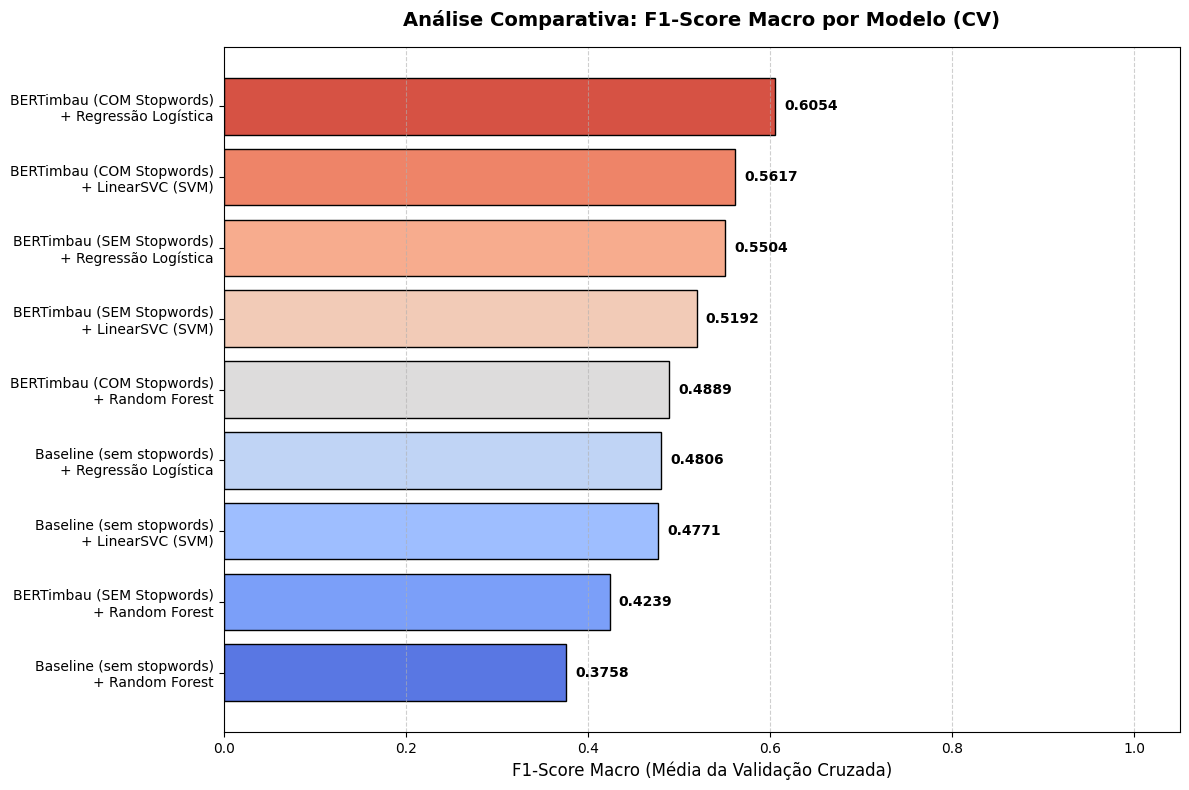

In [ ]:
# gráfico de barras horizontais
df_master_ranking['Identificador_Modelo'] = df_master_ranking['Abordagem'] + "\n+ " + df_master_ranking['Algoritmo']
df_master_ranking = df_master_ranking.sort_values(by="F1-Macro (Validação)", ascending=True)

plt.figure(figsize=(12,8))
cores = sns.color_palette("coolwarm", len(df_master_ranking))
barras = plt.barh(df_master_ranking['Identificador_Modelo'], df_master_ranking['F1-Macro (Validação)'], color=cores, edgecolor='black')
plt.title('Análise Comparativa: F1-Score Macro por Modelo (CV)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('F1-Score Macro (Média da Validação Cruzada)', fontsize=12)
plt.xlim(0,1.05)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for bar in barras:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.611,0.688,0.647,16.000
Elogio - Usabilidade do App,0.111,0.125,0.118,8.000
Elogio - Variedade e Praticidade,0.643,0.600,0.621,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.714,0.750,0.732,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.429,0.300,0.353,10.000
accuracy,0.565,0.565,0.565,0.565
macro avg,0.502,0.492,0.494,69.000
weighted avg,0.563,0.565,0.562,69.000


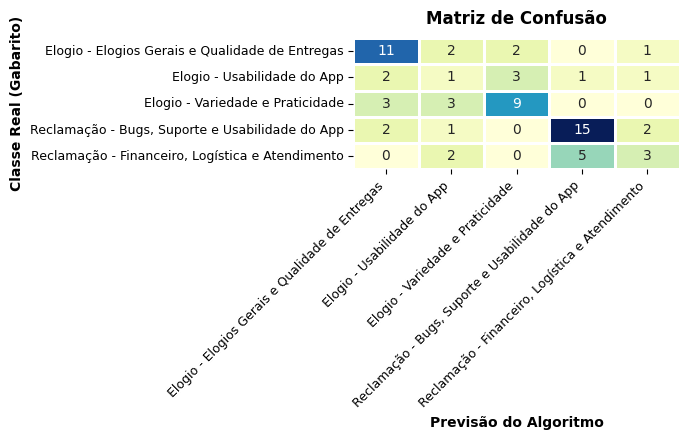

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.667,0.750,0.706,16.000
Elogio - Usabilidade do App,0.167,0.125,0.143,8.000
Elogio - Variedade e Praticidade,0.667,0.667,0.667,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.650,0.650,0.650,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.100,0.100,0.100,10.000
accuracy,0.536,0.536,0.536,0.536
macro avg,0.450,0.458,0.453,69.000
weighted avg,0.522,0.536,0.528,69.000


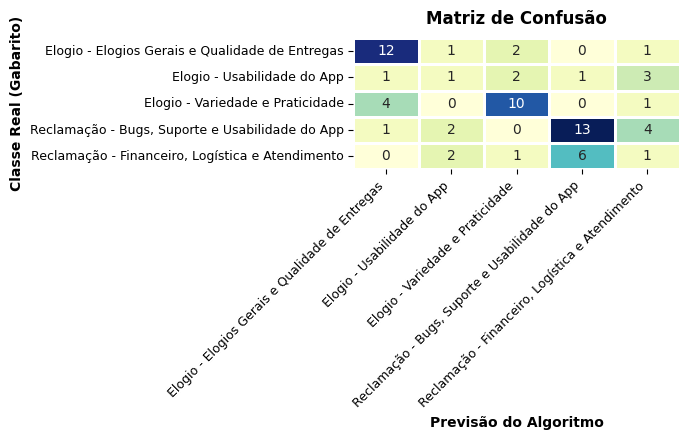

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.583,0.875,0.700,16.000
Elogio - Usabilidade do App,0.143,0.125,0.133,8.000
Elogio - Variedade e Praticidade,0.500,0.400,0.444,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.647,0.550,0.595,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.222,0.200,0.211,10.000
accuracy,0.493,0.493,0.493,0.493
macro avg,0.419,0.430,0.417,69.000
weighted avg,0.480,0.493,0.477,69.000


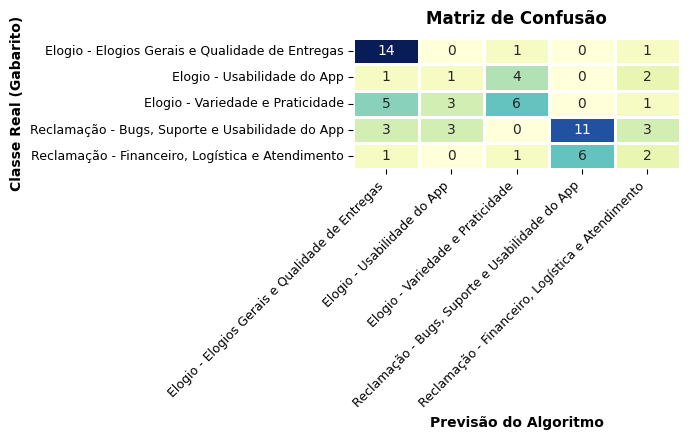

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.609,0.875,0.718,16.000
Elogio - Usabilidade do App,0.333,0.125,0.182,8.000
Elogio - Variedade e Praticidade,0.625,0.667,0.645,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.650,0.650,0.650,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.286,0.200,0.235,10.000
accuracy,0.580,0.580,0.580,0.580
macro avg,0.501,0.503,0.486,69.000
weighted avg,0.545,0.580,0.550,69.000


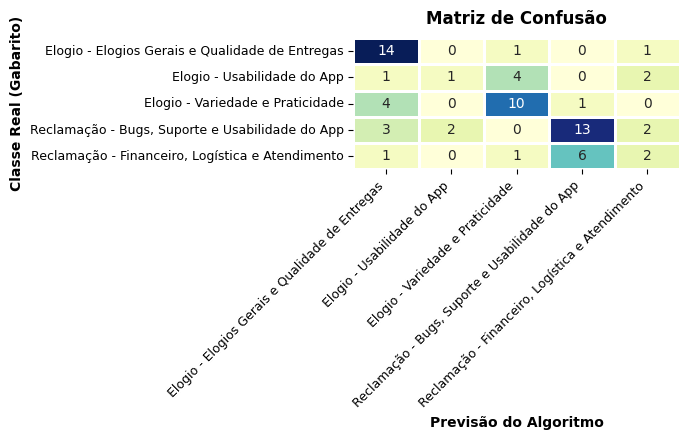

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.579,0.688,0.629,16.000
Elogio - Usabilidade do App,1.000,0.125,0.222,8.000
Elogio - Variedade e Praticidade,0.529,0.600,0.562,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.643,0.900,0.750,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.500,0.200,0.286,10.000
accuracy,0.594,0.594,0.594,0.594
macro avg,0.650,0.503,0.490,69.000
weighted avg,0.624,0.594,0.553,69.000


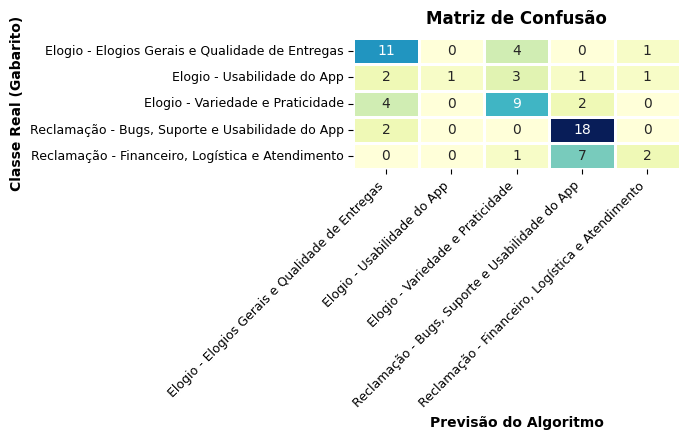

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.467,0.438,0.452,16.000
Elogio - Usabilidade do App,0.273,0.375,0.316,8.000
Elogio - Variedade e Praticidade,0.429,0.400,0.414,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.524,0.550,0.537,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.125,0.100,0.111,10.000
accuracy,0.406,0.406,0.406,0.406
macro avg,0.363,0.372,0.366,69.000
weighted avg,0.403,0.406,0.403,69.000


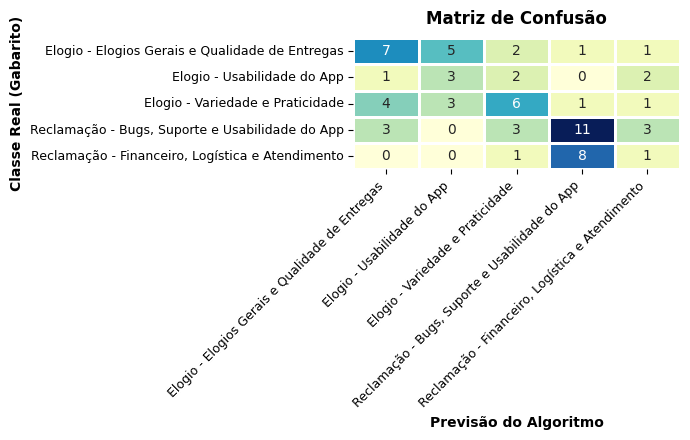

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.500,0.500,0.500,16.000
Elogio - Usabilidade do App,0.300,0.375,0.333,8.000
Elogio - Variedade e Praticidade,0.417,0.333,0.370,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.522,0.600,0.558,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.125,0.100,0.111,10.000
accuracy,0.420,0.420,0.420,0.420
macro avg,0.373,0.382,0.375,69.000
weighted avg,0.411,0.420,0.413,69.000


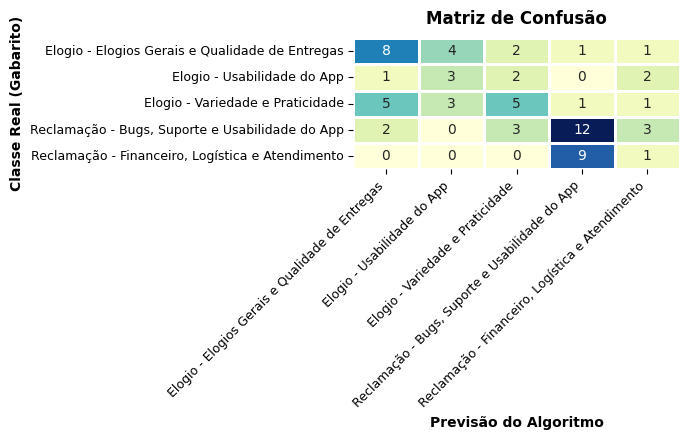

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.750,0.562,0.643,16.000
Elogio - Usabilidade do App,0.000,0.000,0.000,8.000
Elogio - Variedade e Praticidade,0.550,0.733,0.629,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.576,0.950,0.717,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.000,0.000,0.000,10.000
accuracy,0.565,0.565,0.565,0.565
macro avg,0.375,0.449,0.398,69.000
weighted avg,0.460,0.565,0.494,69.000


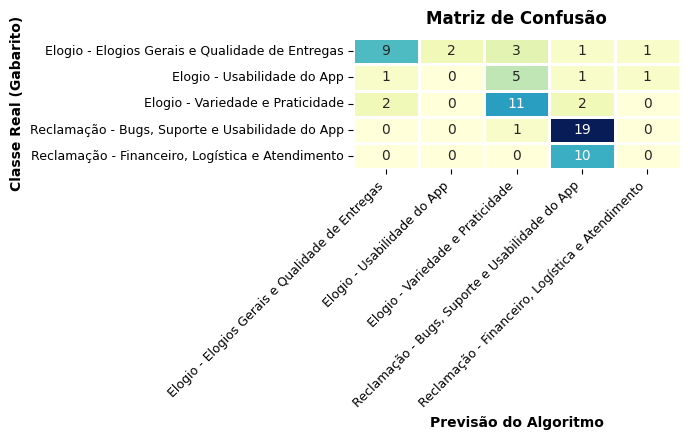

,precision,recall,f1-score,support
Elogio - Elogios Gerais e Qualidade de Entregas,0.333,0.875,0.483,16.000
Elogio - Usabilidade do App,0.000,0.000,0.000,8.000
Elogio - Variedade e Praticidade,0.333,0.267,0.296,15.000
"Reclamação - Bugs, Suporte e Usabilidade do App",0.692,0.450,0.545,20.000
"Reclamação - Financeiro, Logística e Atendimento",0.500,0.100,0.167,10.000
accuracy,0.406,0.406,0.406,0.406
macro avg,0.372,0.338,0.298,69.000
weighted avg,0.423,0.406,0.359,69.000


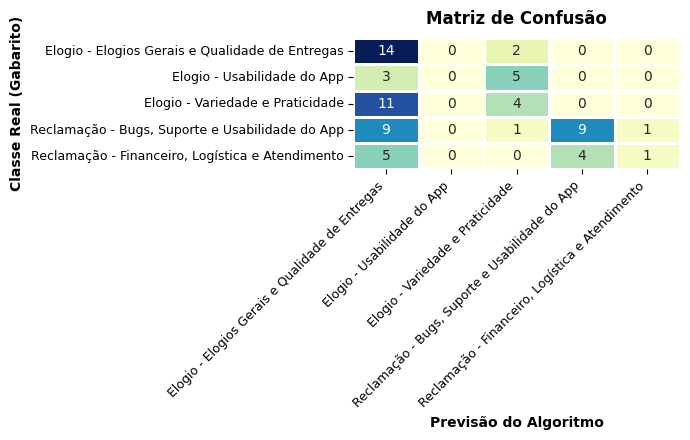

In [ ]:
from IPython.display import display, HTML

# CÓDIGO OBTIDO VIA IA (Google Gemini 3.1 Pro)

df_master_ranking = df_master_ranking.sort_values(by="F1-Macro (Validação)", ascending=False)

for idx, row in df_master_ranking.iterrows():
    m_abordagem = row['Abordagem']
    m_algoritmo = row['Algoritmo']
    modelo_objeto = row['Modelo Treinado']
    dataset_teste = row['Base de Teste']

    # Previsão
    y_pred_modelo = modelo_objeto.predict(dataset_teste)

    # Cálculo das métricas globais
    acc_teste = accuracy_score(y_test, y_pred_modelo)
    f1_macro_teste = f1_score(y_test, y_pred_modelo, average='macro')

    # ---------------------------------------------------------
    # 1. CABEÇALHO VISUAL EM HTML
    # ---------------------------------------------------------
    display(HTML(f"""
    <div style="border: 2px solid #4CAF50; border-radius: 5px; padding: 10px; margin-top: 30px; background-color: #f9f9f9;">
        <h3 style="text-align: center; margin: 0; color: #333;">{m_abordagem} + {m_algoritmo}</h3>
        <p style="text-align: center; margin: 5px 0 0 0; font-size: 14px;">
            <b>Acurácia Global:</b> <span style="color:#2E86C1;">{acc_teste:.4f}</span> |
            <b>F1-Macro:</b> <span style="color:#D35400;">{f1_macro_teste:.4f}</span>
        </p>
    </div>
    """))

    # ---------------------------------------------------------
    # 2. RELATÓRIO DE MÉTRICAS (DataFrame)
    # ---------------------------------------------------------
    # output_dict=True transforma o texto em um dicionário
    report_dict = classification_report(y_test, y_pred_modelo, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report_dict).transpose()

    # Aplica um mapa de calor na tabela para destacar onde o modelo está errando/acertando
    display(df_report.style.background_gradient(
        cmap='Blues', subset=['precision', 'recall', 'f1-score']
    ).format("{:.3f}").set_caption("Métricas Detalhadas por Classe"))

    # ---------------------------------------------------------
    # 3. MATRIZ DE CONFUSÃO
    # ---------------------------------------------------------
    plt.figure(figsize=(7,4.5))
    matriz_individual = confusion_matrix(y_test, y_pred_modelo, labels=modelo_objeto.classes_)

    ax = sns.heatmap(matriz_individual, annot=True, fmt='d', cmap='YlGnBu',
                     xticklabels=modelo_objeto.classes_, yticklabels=modelo_objeto.classes_,
                     cbar=False, linewidths=1, linecolor='white')

    plt.title(f'Matriz de Confusão', fontsize=12, pad=10, fontweight='bold')
    plt.ylabel('Classe Real (Gabarito)', fontsize=10, fontweight='bold')
    plt.xlabel('Previsão do Algoritmo', fontsize=10, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("\n") # Espaçamento para o próximo modelo

In [ ]:
# ----------------------------------------------------------------------
#            Classificações do melhor modelo (erros e acertos)
#             BERTimbau (com stopwords) - Regressão Logística
#-----------------------------------------------------------------------

melhor_modelo_dict = [m for m in todos_os_resultados
                      if m['Abordagem'] == "BERTimbau (COM Stopwords)"
                      and m['Algoritmo'] == "Regressão Logística"][0]

modelo_final = melhor_modelo_dict['Modelo Treinado']
X_test_bert_especifico = melhor_modelo_dict['Base de Teste']

# gera predições
y_pred_final = modelo_final.predict(X_test_bert_especifico)

# textos originais + dataframe
df_resultado_final = pd.DataFrame({
    'Texto_Original': X_test_txt_com,
    'Classe_Real': y_test,
    'Classe_Prevista': y_pred_final
})

# erro
df_resultado_final['Erro'] = df_resultado_final['Classe_Real'] != df_resultado_final['Classe_Prevista']

In [ ]:
# erros
print("Exemplos onde o modelo errou:")
erros = df_resultado_final[df_resultado_final['Erro'] == True]
print(f"Total de erros encontrados: {len(erros)}")
display(erros.sample(min(10, len(erros))))


#acertos
print("\nExemplos onde o modelo acertou:")
acertos = df_resultado_final[df_resultado_final['Erro'] == False]
print(f"Total de acertos encontrados: {len(acertos)}")
display(acertos.sample(min(10, len(acertos))))

Exemplos onde o modelo errou:
Total de erros encontrados: 30


,Texto_Original,Classe_Real,Classe_Prevista,Erro
140,amo delivery much sempre atendendo muito bem,Elogio - Variedade e Praticidade,Elogio - Elogios Gerais e Qualidade de Entregas,True
182,ótimosempre uso appe sempre deu certo obgd,Elogio - Variedade e Praticidade,Elogio - Usabilidade do App,True
5,tento cadastrar meu cartão swile vai voucher f...,"Reclamação - Bugs, Suporte e Usabilidade do App","Reclamação - Financeiro, Logística e Atendimento",True
193,zé delivery ajuda bastante pena que são poucos...,Elogio - Usabilidade do App,"Reclamação - Financeiro, Logística e Atendimento",True
184,fácil de fazer pedidos com grandes descontos,Elogio - Usabilidade do App,Elogio - Variedade e Praticidade,True
294,app sensacional parabéns agora só falta ideali...,Elogio - Variedade e Praticidade,Elogio - Usabilidade do App,True
271,me surpreendi ao perceber que as cervejas vier...,Elogio - Elogios Gerais e Qualidade de Entregas,"Reclamação - Financeiro, Logística e Atendimento",True
3,suporte deixou desejar em vários momentos,"Reclamação - Bugs, Suporte e Usabilidade do App",Elogio - Elogios Gerais e Qualidade de Entregas,True
335,aplicativo bom intuitivo mas precisa melhorar ...,"Reclamação - Financeiro, Logística e Atendimento",Elogio - Usabilidade do App,True
83,app muito bom,Elogio - Elogios Gerais e Qualidade de Entregas,Elogio - Usabilidade do App,True



Exemplos onde o modelo acertou:
Total de acertos encontrados: 39


,Texto_Original,Classe_Real,Classe_Prevista,Erro
306,vocês precisam melhorar opção de entrega onde ...,"Reclamação - Bugs, Suporte e Usabilidade do App","Reclamação - Bugs, Suporte e Usabilidade do App",False
90,coloquem opção de transferir pro banco de orig...,"Reclamação - Financeiro, Logística e Atendimento","Reclamação - Financeiro, Logística e Atendimento",False
334,depois da penúltima atualização no celular red...,"Reclamação - Bugs, Suporte e Usabilidade do App","Reclamação - Bugs, Suporte e Usabilidade do App",False
191,excelente chegou antes do horário,Elogio - Elogios Gerais e Qualidade de Entregas,Elogio - Elogios Gerais e Qualidade de Entregas,False
187,estou tendo problemas em adicionar um novo end...,"Reclamação - Bugs, Suporte e Usabilidade do App","Reclamação - Bugs, Suporte e Usabilidade do App",False
256,melhor entrega cerveja super gelada parabéns,Elogio - Elogios Gerais e Qualidade de Entregas,Elogio - Elogios Gerais e Qualidade de Entregas,False
289,nao tem nenhuma aba nesse aplicativo que mostr...,"Reclamação - Bugs, Suporte e Usabilidade do App","Reclamação - Bugs, Suporte e Usabilidade do App",False
102,ótimo aplicativo melhor aplicativo de comida d...,Elogio - Variedade e Praticidade,Elogio - Variedade e Praticidade,False
147,prefiro não avaliar antes de receber,"Reclamação - Financeiro, Logística e Atendimento","Reclamação - Financeiro, Logística e Atendimento",False
61,muito bom amo as entregase nunca veio errado a...,Elogio - Elogios Gerais e Qualidade de Entregas,Elogio - Elogios Gerais e Qualidade de Entregas,False


## **Classificação de Novos Comentários**

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd

apps_alvo = {
    'iFood': 'br.com.brainweb.ifood',
    'Delivery Much': 'br.com.deliverymuch.gastro',
    'Zé Delivery': 'com.cerveceriamodelo.modelonow',
    'Pigz': 'app.pigz.mart'
}

novos_comentarios = []

for app_name, app_id in apps_alvo.items():
    print(f"Coletando 10 novos comentários de {app_name}...")
    result, _ = reviews(
        app_id,
        lang='pt',
        country='br',
        sort=Sort.NEWEST,
        count=10 # 10 de cada
    )
    for review in result:
        review['app'] = app_name
        novos_comentarios.append(review)

df_novos = pd.DataFrame(novos_comentarios)
print(f"\nTotal de novos comentários coletados: {len(df_novos)}")

Coletando 10 novos comentários de iFood...
Coletando 10 novos comentários de Delivery Much...
Coletando 10 novos comentários de Zé Delivery...
Coletando 10 novos comentários de Pigz...

Total de novos comentários coletados: 40


In [ ]:
df_novos.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app,classe_prevista
0,6296110a-ac21-4246-b369-e553584bd294,Marisa De Moura,https://play-lh.googleusercontent.com/a-/ALV-U...,muito bom,5,0,10.128.0,2026-06-29 23:06:23,None,None,10.128.0,iFood,Elogio - Elogios Gerais e Qualidade de Entregas
1,bbca06b4-4794-45d8-b252-45ab42a458a6,marcos daniel,https://play-lh.googleusercontent.com/a-/ALV-U...,muito mesmo.,5,0,10.128.0,2026-06-29 22:57:33,None,None,10.128.0,iFood,Elogio - Elogios Gerais e Qualidade de Entregas
2,0fddffc3-d3ce-4da1-8305-a4dfaaa366bc,josué gabriel,https://play-lh.googleusercontent.com/a-/ALV-U...,"ótimo ,bom pra ser entregador,e fazer pedidos,...",5,0,10.128.0,2026-06-29 22:54:23,None,None,10.128.0,iFood,Elogio - Elogios Gerais e Qualidade de Entregas
3,4af39adb-e5a0-476d-a73a-c71267e9d013,Giovana Gonçalves,https://play-lh.googleusercontent.com/a/ACg8oc...,"péssima experiência, pois fiz uma compra e a m...",1,0,10.128.0,2026-06-29 22:50:30,None,None,10.128.0,iFood,"Reclamação - Financeiro, Logística e Atendimento"
4,5c92e4a1-1c33-465a-8400-87d93a2168d4,Ademilson Ferreira Do Nascimento,https://play-lh.googleusercontent.com/a-/ALV-U...,top,5,0,10.128.0,2026-06-29 22:50:23,None,None,10.128.0,iFood,Elogio - Elogios Gerais e Qualidade de Entregas


In [ ]:
# FUNÇÃO OBTIDA VIA IA (Google Gemini 3.1 Pro)

def classificar(modelo, textos, modelo_bert=None):
    """
    Classifica textos e retorna a classe prevista e a probabilidade
    """
    # preparação dos dados
    if 'vetorizador' in modelo.named_steps:
        data = textos
    else:
        # Assumimos que é BERT e precisa de encoding
        data = modelo_bert.encode(textos.tolist(), show_progress_bar=False, normalize_embeddings=True)

    # predição da classe
    predicoes = modelo.predict(data)

    #cálculo da confiança (probabilidades)
    if hasattr(modelo, "predict_proba"):
        #pega a probabilidade da classe vencedora
        confiancas = modelo.predict_proba(data).max(axis=1)
    else:
        # fallback caso seja LinearSVC ou outro modelo sem proba nativa
        confiancas = [None]*len(predicoes)
        print("Aviso: O modelo não fornece probabilidades (ex: LinearSVC).")

    return predicoes, confiancas

In [ ]:
df_ranking = pd.DataFrame(todos_os_resultados)
melhor_modelo_row = df_ranking.sort_values(by="F1-Macro (Validação)", ascending=False).iloc[0]
modelo_melhor = melhor_modelo_row['Modelo Treinado']

novos_textos = df_novos['content'].fillna('')
predicoes, confiancas = classificar(modelo_melhor, novos_textos, modelo_bert)

df_novos['classe_prevista'] = predicoes
df_novos['confianca'] = confiancas

In [ ]:
#visualização
display(df_novos[['app', 'content', 'classe_prevista', 'confianca', 'score']].head(40))

,app,content,classe_prevista,confianca,score
0,iFood,muito bom,Elogio - Elogios Gerais e Qualidade de Entregas,0.393692,5
1,iFood,muito mesmo.,Elogio - Elogios Gerais e Qualidade de Entregas,0.403949,5
2,iFood,"ótimo ,bom pra ser entregador,e fazer pedidos,...",Elogio - Elogios Gerais e Qualidade de Entregas,0.272071,5
3,iFood,"péssima experiência, pois fiz uma compra e a m...","Reclamação - Financeiro, Logística e Atendimento",0.319471,1
4,iFood,top,Elogio - Elogios Gerais e Qualidade de Entregas,0.311956,5
5,iFood,app PÉSSIMO! Se eu pudesse dar 0 estrelas eu f...,"Reclamação - Bugs, Suporte e Usabilidade do App",0.269010,1
6,iFood,O Ifood é ótimo!,Elogio - Elogios Gerais e Qualidade de Entregas,0.312825,5
7,iFood,muito bom,Elogio - Elogios Gerais e Qualidade de Entregas,0.393692,5
8,iFood,muito bom.,Elogio - Elogios Gerais e Qualidade de Entregas,0.397058,5
9,iFood,boa mais só não tou entendendo como funciona o...,"Reclamação - Financeiro, Logística e Atendimento",0.288808,5


No geral, o melhor modelo conseguiu prever corretamente as classificações. Nota-se, no entanto, um erro no index **37**. O modelo era, em especial, por conta palavra "app", que para a classe "_Elogio - Usabilidade do App_", é normalmente decisiva.